# Weight of Evidence (WoE) Binning and Information Value (IV) Selection

In this notebook, we perform Weight of Evidence (WoE) binning for both categorical and continuous variables. WoE transforms variables into a format suitable for logistic regression models used in credit risk scorecards.

The objectives of this notebook are:

• Calculate WoE for categorical and numerical variables  
• Perform binning for continuous variables  
• Analyze event rate behavior across bins  
• Compute Information Value (IV) for each variable  
• Select predictive variables for PD model development  

This step prepares the dataset for the logistic regression Probability of Default (PD) model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("../data/processed/loan_data_cleaned.csv")

### Extract Loan Origination Year

For portfolio-level credit risk analysis, we require the **year in which each loan was originated**.  
The LendingClub dataset records this information in the `issue_d` (issue date) column.

For the **Vasicek asset correlation estimation**, defaults must be aggregated by **calendar year** in order to compute the **observed default rate per year**. These yearly default rates are later used to estimate the **systematic asset correlation parameter (ρ)**.

Therefore, we extract the **year component** from the `issue_d` variable.

In [3]:
df['issue_d'].head(10)

0    Dec-11
1    Dec-11
2    Dec-11
3    Dec-11
4    Dec-11
5    Dec-11
6    Dec-11
7    Dec-11
8    Dec-11
9    Dec-11
Name: issue_d, dtype: object

In [4]:
# ── Extract year from issue_date ─────────────────────────
df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')

df['year'] = df['issue_date'].dt.year

df[['issue_date','year']].head()

,issue_date,year
0,2011-12-01,2011
1,2011-12-01,2011
2,2011-12-01,2011
3,2011-12-01,2011
4,2011-12-01,2011


### Prepare Dataset for Vasicek Asset Correlation Estimation

To estimate the Vasicek asset correlation parameter (ρ), we require a time series of observed default rates.

This requires two variables:
- **year** — loan origination year
- **default** — default indicator (1 = default, 0 = non-default)

Defaults will later be aggregated by year to compute the **observed annual default rate**, which forms the basis for estimating the systematic asset correlation in the Vasicek single-factor credit risk model.

Therefore, we export a minimal dataset containing only these variables for use in the portfolio risk modelling stage.

In [5]:
# ── Export dataset for Vasicek modelling ─────────────────
vasicek_pd_data = df[['year', 'default']]

vasicek_pd_data.to_pickle("../data/processed/vasicek_pd_data.pkl")

print("Vasicek dataset exported successfully")

Vasicek dataset exported successfully


In [6]:
df.shape

(230795, 52)

In [7]:
df.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan',
       'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'default', 'term_month', 'emp_length_years',
       'months_since_earliest_cr_line', 'issue_date',
       'months_since_issue_date', 'mths_since_last_delinq_missing',
       'annual_inc_missing', 'emp_length_missing',
       'mths_since_last_record_missing', 'mths_since_last_major_derog_missing',
       'tot_cur_bal_missing', 'total_rev_hi_lim

## Separate Input Features and Target Variable

In this step, we separate the dataset into:

**Target Variable (y):**

The target variable represents the loan outcome that the model will attempt to predict.  
In this project, the target variable is **`default`**, where:

- **1 = Default (Bad loan)**
- **0 = Non-default (Good loan)**

**Input Features (X):**

The input features consist of all remaining variables in the dataset that may help predict the probability of default.  
These variables include borrower characteristics, loan characteristics, and credit history indicators.

The target variable is removed from the input dataset to avoid data leakage during model development.

In [8]:
# Define target variable
y = df['default']

# Define input variables
X = df.drop(['default'], axis=1)

print("Input features shape:", X.shape)
print("Target variable shape:", y.shape)

Input features shape: (230795, 51)
Target variable shape: (230795,)


## Remove Redundant, Leakage, and Raw Date Variables

Before performing Weight of Evidence (WoE) binning, we remove several variables that are either redundant, non-informative, or may introduce data leakage into the model.

**policy_code**
- This variable is constant in the LendingClub dataset and therefore contains no predictive information.

**loan_status**
- The target variable `default` was derived from this column.
- Keeping it would introduce **target leakage**, since it directly reveals the loan outcome.

**pymnt_plan**
- This variable has almost no variation (nearly all values are "n"), providing negligible predictive power.

**zip_code**
- Zip codes create very high cardinality categories and extremely sparse groups.
- In credit risk models, geographic information is typically aggregated (e.g., by state) for stability.

**grade**
- The `grade` variable is derived from the more granular `sub_grade`.
- Keeping both introduces redundant information, so we retain `sub_grade` and drop `grade`.

**term**
- The original `term` column is stored as a string (e.g., "36 months").
- A numeric version (`term_month`) was engineered earlier and will be used for modeling instead.

**issue_date / issue_d**
- These columns contain raw loan issue dates.
- Since `months_since_issue_date` has already been engineered, the raw date variables are unnecessary and may cause issues during WoE binning.

Removing these variables ensures that only meaningful, non-leaking predictors remain for the WoE transformation and subsequent model development.

In [9]:
X = X.drop([
       'policy_code',
    'loan_status',
    'pymnt_plan',
    'zip_code',
    'grade',
    'term',
    'issue_date',
    'issue_d'
], axis=1)

X.shape

(230795, 43)

## Train-Test Split
To avoid data leakage, the dataset is split into training and testing sets before performing WoE binning.  
WoE bins will be created using the training data only and then applied to the test data.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (184636, 43)
Test set shape: (46159, 43)


In [11]:
train_data = X_train.copy()
train_data['default'] = y_train.copy()

test_data = X_test.copy()
test_data['default'] = y_test.copy()

In [12]:
X.shape

(230795, 43)

In [13]:
X.select_dtypes(include='object').columns

Index(['sub_grade', 'home_ownership', 'verification_status', 'purpose',
       'addr_state', 'initial_list_status', 'application_type'],
      dtype='object')

## WoE and IV: The Mathematics

Weight of Evidence (WoE) is a monotonic transformation applied to each category (or bin) of a variable.
It measures how strongly a bin separates Good borrowers (non-default) from Bad borrowers (default).

---

### Step 1: Count Observations per Bin

For each category of a variable, we count:

- **n_obs** — total number of observations in that bin
- **n_good** — number of non-defaults (target = 0)
- **n_bad** — number of defaults (target = 1)

---

### Step 2: Compute Global Proportions

We then express each bin's goods and bads as a **proportion of the total goods and bads** in the entire dataset:

$$\text{prop\_good}_i = \frac{\text{n\_good}_i}{\sum \text{n\_good}}$$

$$\text{prop\_bad}_i = \frac{\text{n\_bad}_i}{\sum \text{n\_bad}}$$

These are not event rates within a bin — they are each bin's **share of the total good/bad population**.

---

### Step 3: Compute Weight of Evidence

$$\text{WoE}_i = \ln\left(\frac{\text{prop\_good}_i}{\text{prop\_bad}_i}\right)$$

**Interpretation:**

| WoE value | Meaning |
|-----------|---------|
| Positive | Bin has a higher share of Goods than Bads → lower default risk |
| Zero | Bin's good/bad split mirrors the overall population |
| Negative | Bin has a higher share of Bads than Goods → higher default risk |

> **Zero-count smoothing:** If any bin has zero goods or zero bads, the log is undefined.
> We add 0.5 to all counts before computing proportions to avoid this.

---

### Step 4: Compute Information Value

IV measures the **overall predictive power** of a variable by summing across all its bins:

$$\text{IV} = \sum_{i=1}^{n} \left(\text{prop\_good}_i - \text{prop\_bad}_i\right) \times \text{WoE}_i$$

**IV selection thresholds used in this project:**

| IV range | Predictive power | Decision |
|----------|-----------------|---------|
| < 0.02 | Useless | Drop |
| 0.02 – 0.1 | Weak | Consider dropping |
| 0.1 – 0.3 | Medium | Keep |
| 0.3 – 0.5 | Strong | Keep |
| > 0.5 | Suspicious | Investigate for leakage |

## Define WoE Function for Discrete Variables
Weight of Evidence (WoE) is a transformation widely used in credit risk scorecard modeling.
It converts categorical variables into numerical values that represent the relationship between each category and the probability of default.

The WoE for a category is defined as:

WoE = ln(% of Good / % of Bad)

Where:

% Good = proportion of non-default observations in the category
% Bad = proportion of default observations in the category
WoE provides several advantages in credit risk modeling:

• Captures the predictive relationship between features and default risk
• Handles categorical variables effectively
• Produces variables suitable for logistic regression
• Enables calculation of Information Value (IV) for variable selection

In the following step, we define a reusable function to compute WoE and IV for discrete (categorical) variables.

In [14]:
def woe_discrete(df, discrete_variable_name, good_bad_variable_df):
    """
    Computes WoE and IV for a single discrete (categorical) variable.
    
    Parameters:
    - df: feature DataFrame (X_train)
    - discrete_variable_name: column name (string)
    - good_bad_variable_df: target Series (y_train), 1 = bad, 0 = good
    
    Returns:
    - df1: DataFrame with WoE, IV, and supporting columns per category
    """
    df = pd.concat([df[discrete_variable_name], good_bad_variable_df], axis=1)
    
    df = pd.concat([
        df.groupby(df.columns.values[0], as_index=False)[df.columns.values[1]].count(),
        df.groupby(df.columns.values[0], as_index=False)[df.columns.values[1]].mean()
    ], axis=1)
    
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    
    # Smoothing: add 0.5 to avoid log(0) when a bin has no goods or no bads
    n_bins = len(df)
    df['prop_n_good'] = (df['n_good'] + 0.5) / (df['n_good'].sum() + 0.5 * n_bins)
    df['prop_n_bad']  = (df['n_bad']  + 0.5) / (df['n_bad'].sum()  + 0.5 * n_bins)
    
    
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    
    df = df.sort_values(['WoE'])
    df = df.reset_index(drop=True)
    
    df['diff_prop_good'] = df['prop_n_good'].diff().abs()
    df['diff_WoE']       = df['WoE'].diff().abs()
    
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    
    return df

In [15]:
def plot_by_woe(df_woe, rotation_of_x_axis_labels=0):
    """
    Plots WoE values per category as a line chart.
    Sorted by WoE so you can visually inspect the risk ordering.
    """
    x = np.array(df_woe.iloc[:, 0].apply(str))
    y = df_woe['WoE']
    
    plt.figure(figsize=(18, 6))
    plt.plot(x, y, marker='o', linestyle='--', color='k')
    plt.xlabel(str(df_woe.columns[0]))
    plt.ylabel('Weight of Evidence')
    plt.title('Weight of Evidence by ' + str(df_woe.columns[0]))
    plt.xticks(rotation=rotation_of_x_axis_labels)
    plt.show()

In [16]:
# Test on sub_grade first — it should show a very clean monotonic WoE pattern
df_temp = woe_discrete(X_train, 'sub_grade', y_train)
df_temp

,sub_grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,A1,4378,0.032206,0.023712,141.0,4237.0,0.004012,0.028364,-1.955880,NaN,NaN,0.42125
1,A2,4538,0.048480,0.024578,220.0,4318.0,0.006252,0.028906,-1.531217,0.002240,0.424663,0.42125
2,A3,5327,0.056505,0.028851,301.0,5026.0,0.008548,0.033645,-1.370161,0.002296,0.161057,0.42125
3,A4,8240,0.072937,0.044628,601.0,7639.0,0.017053,0.051135,-1.098112,0.008505,0.272048,0.42125
4,A5,8694,0.088797,0.047087,772.0,7922.0,0.021902,0.053029,-0.884281,0.004848,0.213831,0.42125
5,B1,8963,0.106438,0.048544,954.0,8009.0,0.027062,0.053611,-0.683647,0.005160,0.200634,0.42125
6,B2,10966,0.117728,0.059393,1291.0,9675.0,0.036616,0.064763,-0.570244,0.009554,0.113403,0.42125
7,B3,13605,0.129364,0.073686,1760.0,11845.0,0.049913,0.079287,-0.462802,0.013297,0.107442,0.42125
8,B4,12617,0.144805,0.068334,1827.0,10790.0,0.051812,0.072226,-0.332169,0.001900,0.130633,0.42125
9,B5,10464,0.162366,0.056674,1699.0,8765.0,0.048183,0.058672,-0.196941,0.003629,0.135228,0.42125


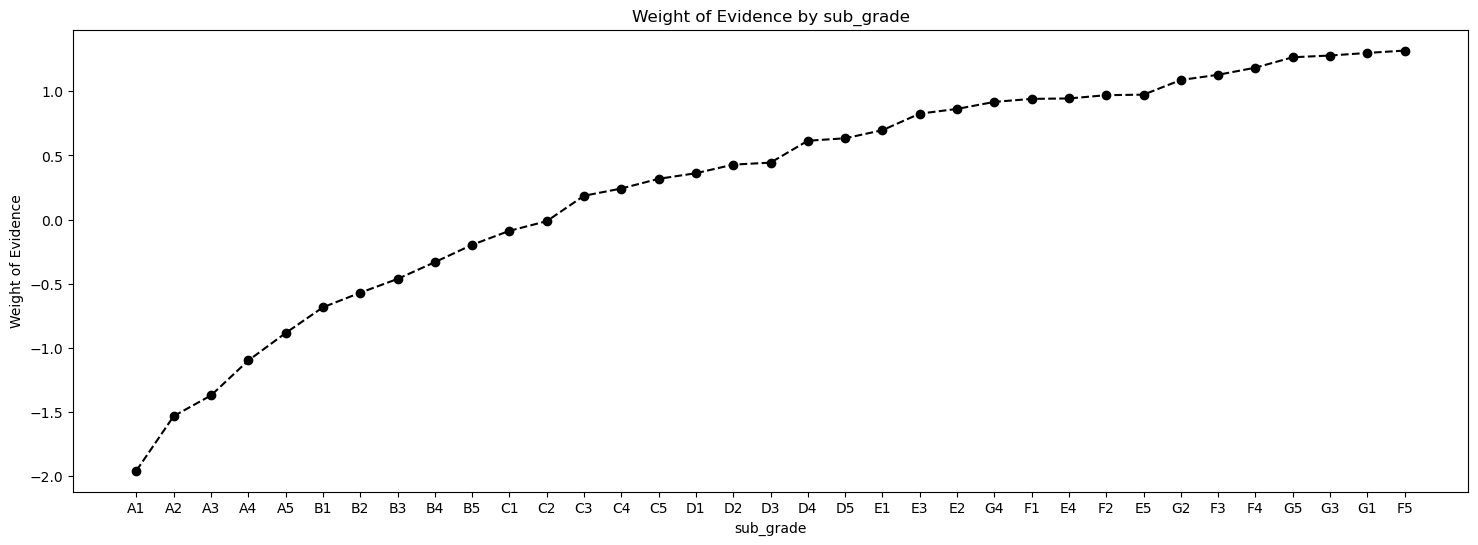

In [17]:
plot_by_woe(df_temp)

sub_grade: IV = 0.4213


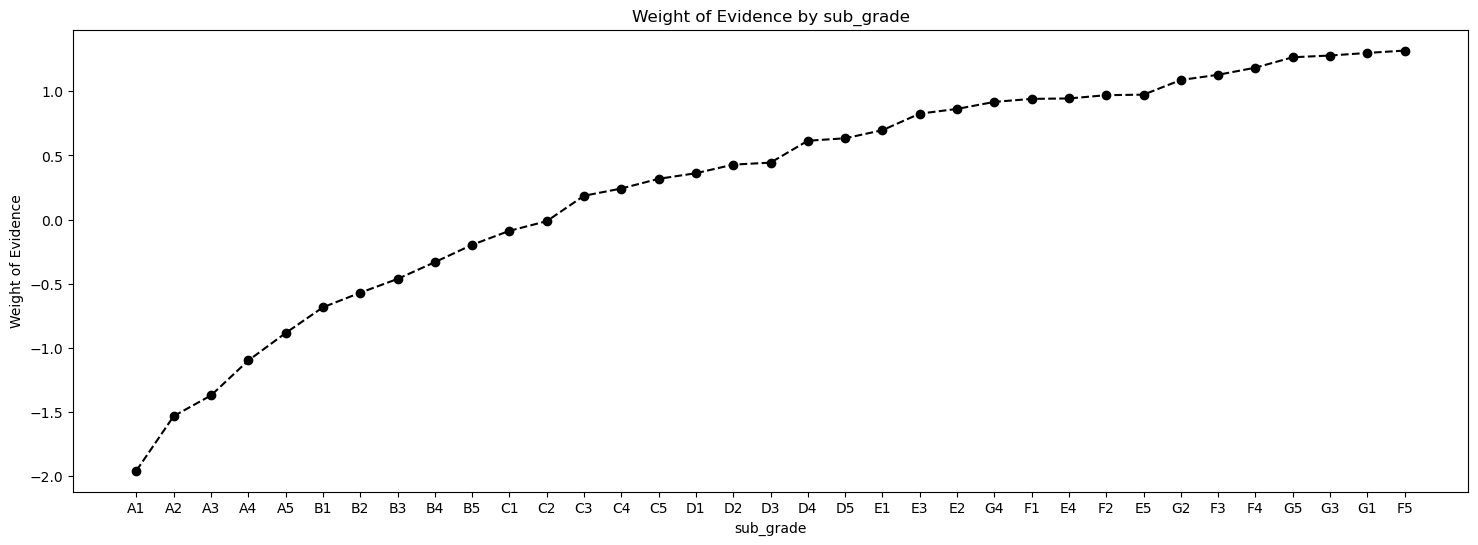

home_ownership: IV = 0.0148


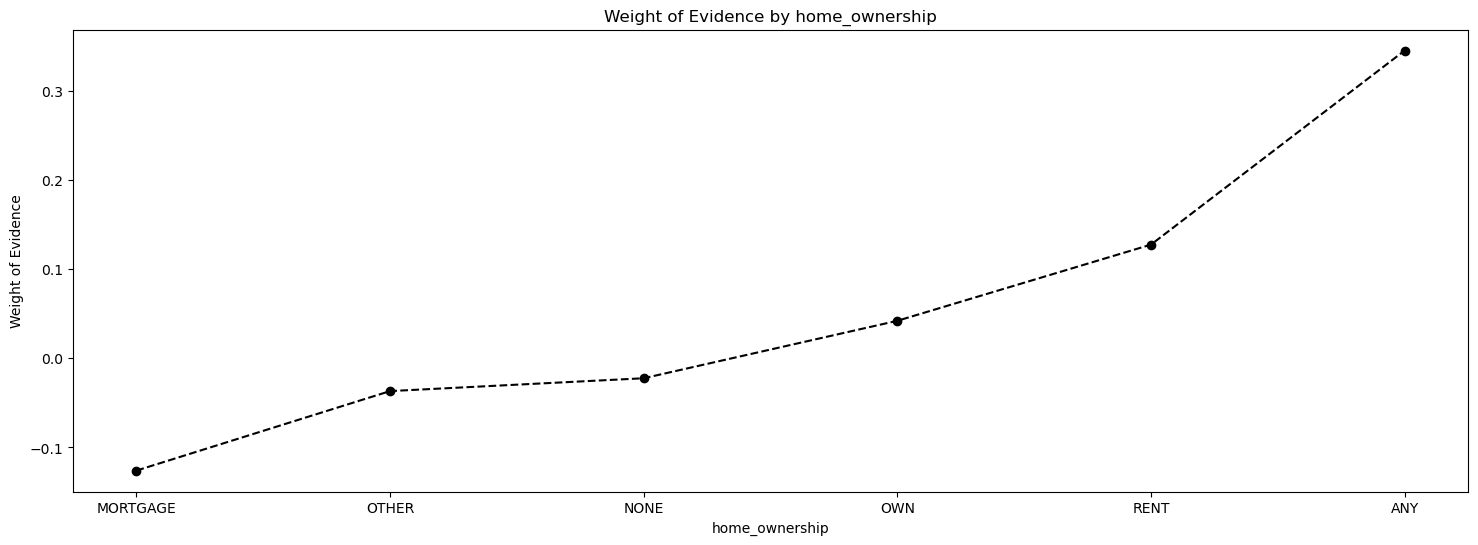

verification_status: IV = 0.0376


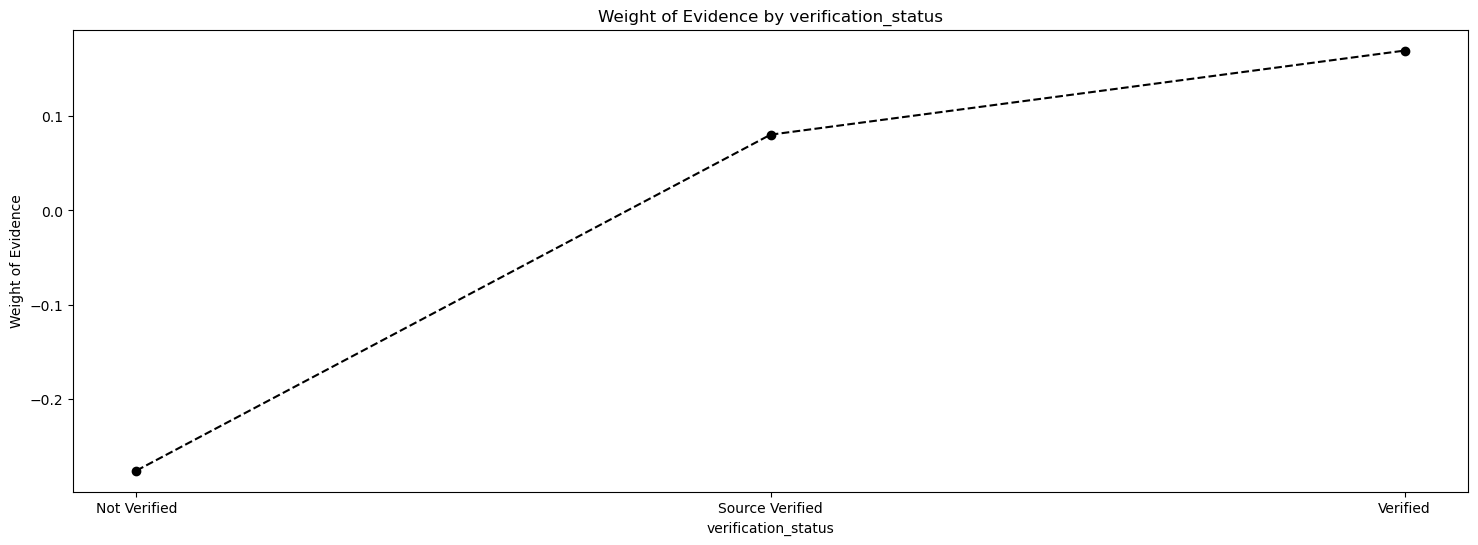

purpose: IV = 0.0275


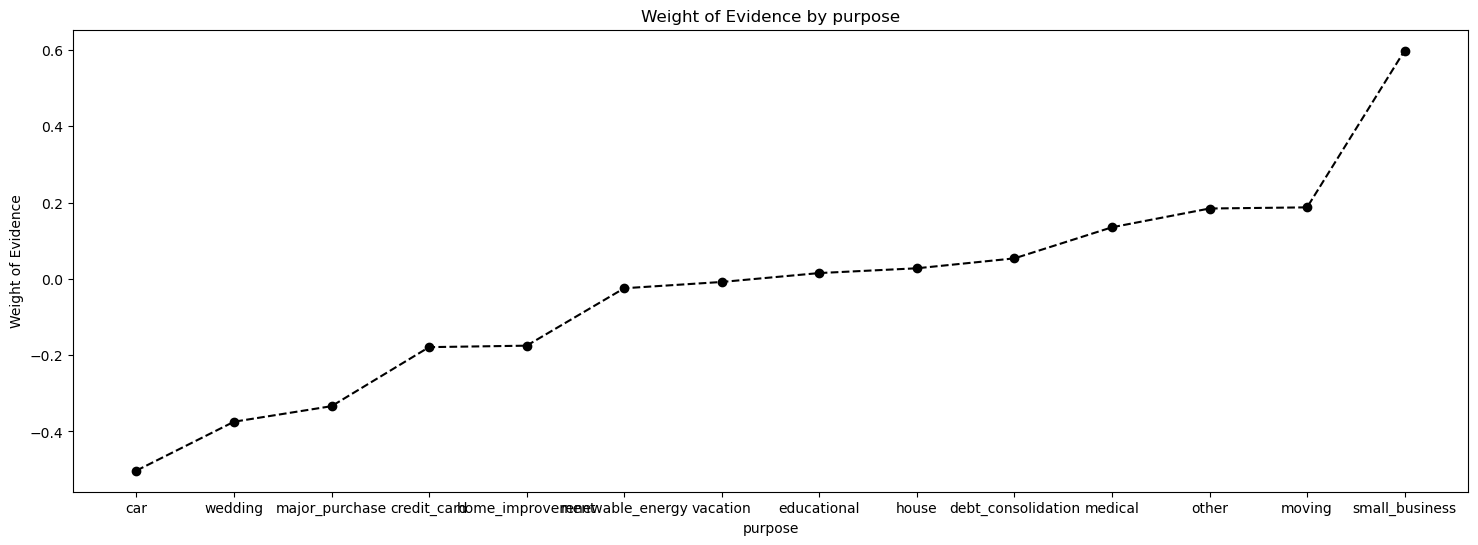

addr_state: IV = 0.0155


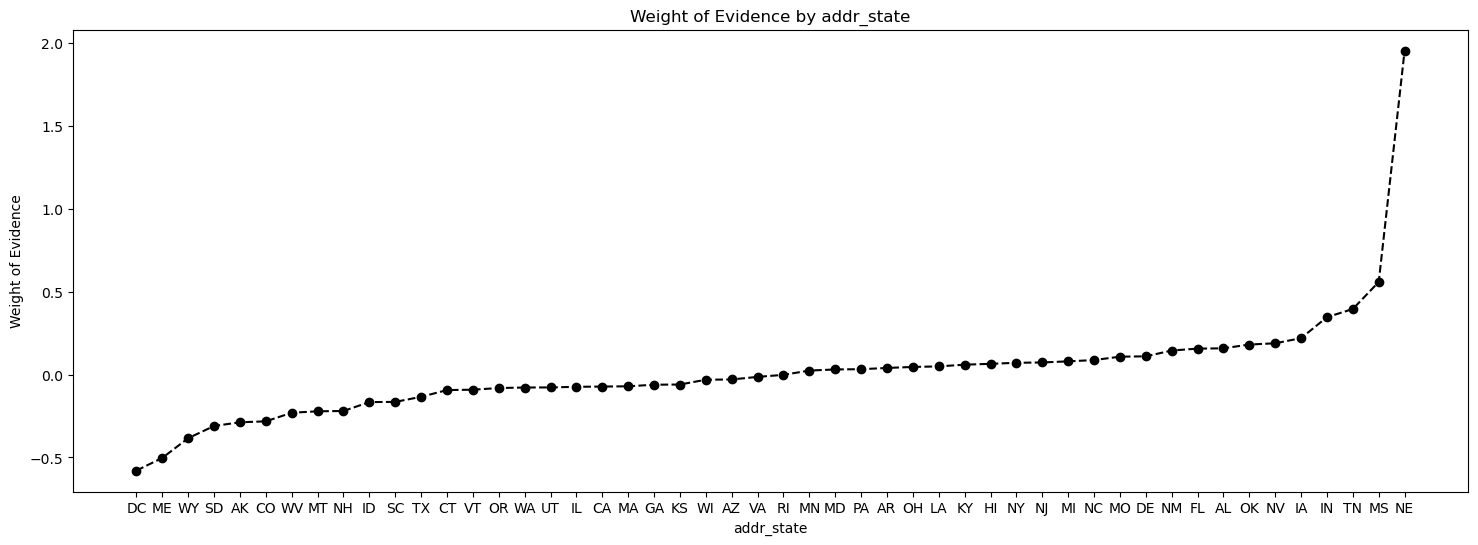

initial_list_status: IV = 0.0010


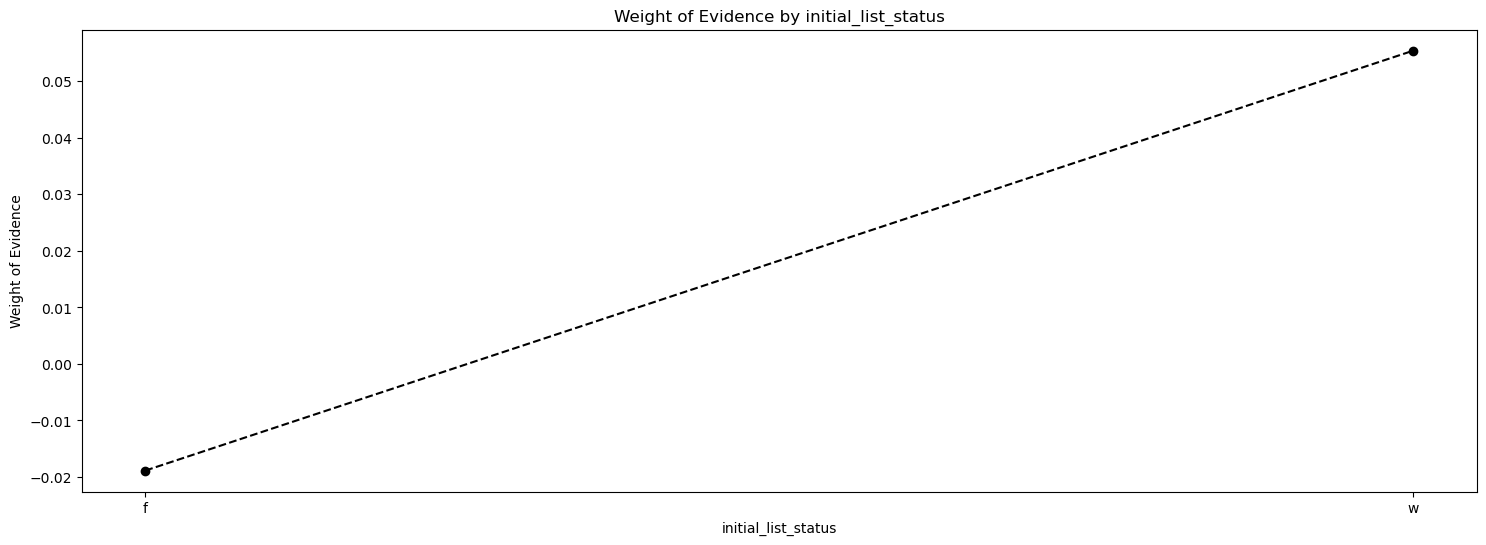

application_type: IV = 0.0000


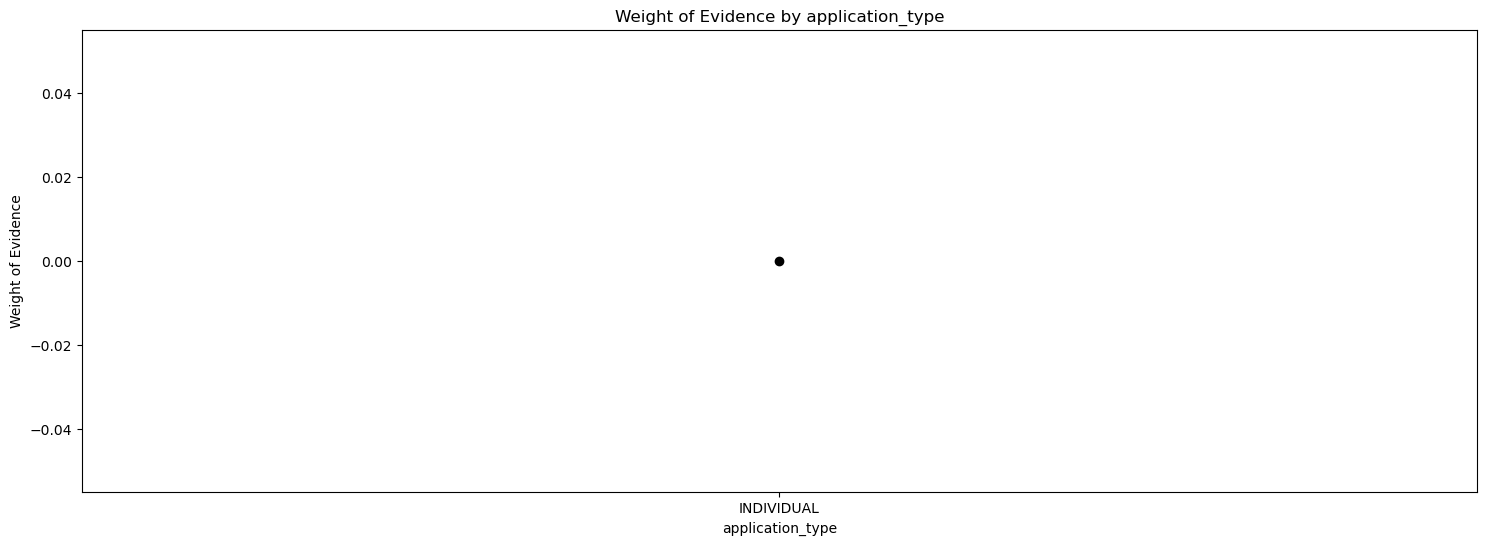

In [18]:
# Object type columns from earlier check
discrete_cols = ['sub_grade', 'home_ownership', 'verification_status',
                 'purpose', 'addr_state', 'initial_list_status', 'application_type']

iv_summary = {}

for col in discrete_cols:
    df_temp = woe_discrete(X_train, col, y_train)
    iv_summary[col] = df_temp['IV'].iloc[0]
    print(f"{col}: IV = {df_temp['IV'].iloc[0]:.4f}")
    plot_by_woe(df_temp)

## Remove Non-Predictive Variables

The variable `application_type` has an Information Value (IV) of approximately zero and contains only a single category.  
Therefore, it does not provide predictive information and is removed from the modeling dataset.

In [19]:
X_train = X_train.drop(columns=['application_type'])
X_test  = X_test.drop(columns=['application_type'])

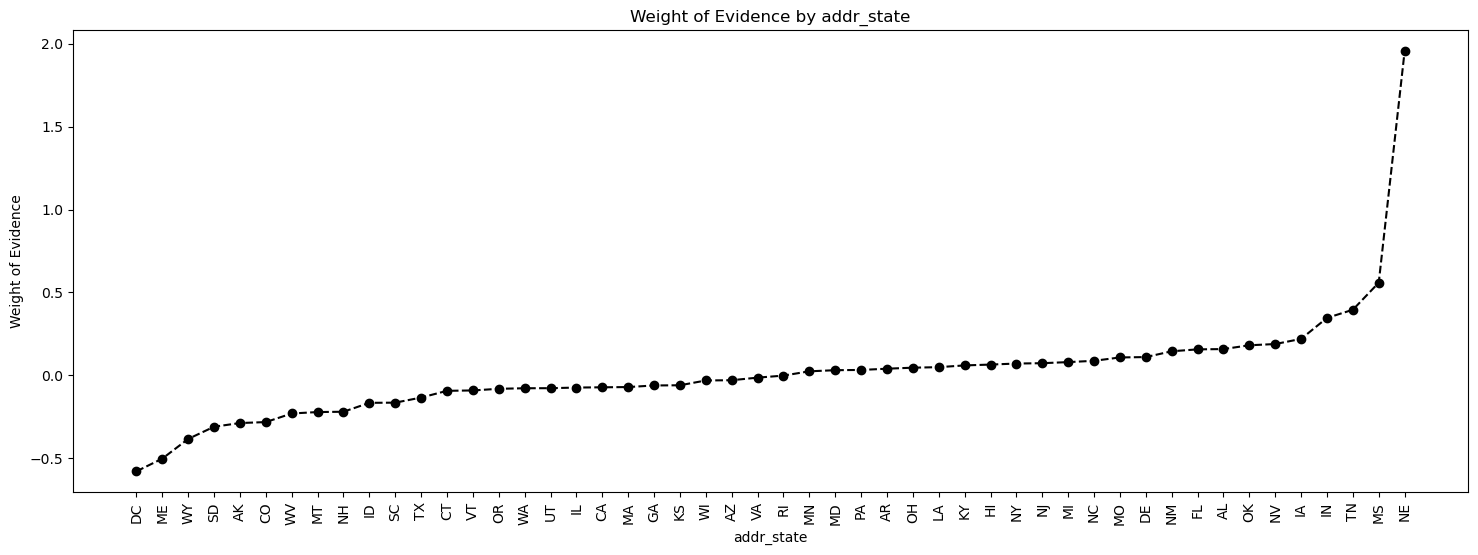

In [20]:
df_temp = woe_discrete(X_train, 'addr_state', y_train)
plot_by_woe(df_temp, rotation_of_x_axis_labels=90)

In [21]:
df_temp[['addr_state', 'n_obs', 'prop_good', 'WoE', 'IV']].sort_values('WoE')

,addr_state,n_obs,prop_good,WoE,IV
0,DC,628,0.116242,-0.579197,0.015494
1,ME,3,0.000000,-0.502524,0.015494
2,WY,450,0.137778,-0.383740,0.015494
3,SD,375,0.146667,-0.310113,0.015494
4,AK,481,0.149688,-0.287964,0.015494
5,CO,4031,0.151079,-0.282101,0.015494
6,WV,838,0.157518,-0.230354,0.015494
7,MT,549,0.158470,-0.221622,0.015494
8,NH,818,0.158924,-0.219756,0.015494
9,ID,8,0.125000,-0.166052,0.015494


In [22]:
# First create dummies for addr_state on train and test
X_train = pd.get_dummies(X_train, columns=['addr_state'])
X_test  = pd.get_dummies(X_test,  columns=['addr_state'])

# Align — test may be missing states seen in train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [23]:
# Change every 'addr_state:DC' to 'addr_state_DC' throughout
X_train['addr_state:very_risky'] = sum([X_train['addr_state_DC'],
                                         X_train['addr_state_MS'],
                                         X_train['addr_state_NV'],
                                         X_train['addr_state_SD'],
                                         X_train['addr_state_AK']])

X_test['addr_state:very_risky']  = sum([X_test['addr_state_DC'],
                                         X_test['addr_state_MS'],
                                         X_test['addr_state_NV'],
                                         X_test['addr_state_SD'],
                                         X_test['addr_state_AK']])

In [24]:
# Group 2: below average risk (WoE -0.3 to -0.15)
X_train['addr_state:below_avg'] = sum([X_train['addr_state_CO'],
                                        X_train['addr_state_WY'],
                                        X_train['addr_state_MT'],
                                        X_train['addr_state_NH'],
                                        X_train['addr_state_ID'],
                                        X_train['addr_state_SC'],
                                        X_train['addr_state_TX'],
                                        X_train['addr_state_CT'],
                                        X_train['addr_state_VT']])

X_test['addr_state:below_avg']  = sum([X_test['addr_state_CO'],
                                        X_test['addr_state_WY'],
                                        X_test['addr_state_MT'],
                                        X_test['addr_state_NH'],
                                        X_test['addr_state_ID'],
                                        X_test['addr_state_SC'],
                                        X_test['addr_state_TX'],
                                        X_test['addr_state_CT'],
                                        X_test['addr_state_VT']])

In [25]:
# Group 3: average risk — the large middle cluster (WoE -0.15 to +0.15)
# This is the reference/baseline group in logistic regression
# We keep it but will likely DROP it to avoid dummy variable trap
X_train['addr_state:average'] = sum([X_train['addr_state_OR'],
                                      X_train['addr_state_WA'],
                                      X_train['addr_state_IL'],
                                      X_train['addr_state_CA'],
                                      X_train['addr_state_MA'],
                                      X_train['addr_state_GA'],
                                      X_train['addr_state_KS'],
                                      X_train['addr_state_WI'],
                                      X_train['addr_state_VA'],
                                      X_train['addr_state_RI'],
                                      X_train['addr_state_MN'],
                                      X_train['addr_state_MD'],
                                      X_train['addr_state_AR'],
                                      X_train['addr_state_AZ'],
                                      X_train['addr_state_OK'],
                                      X_train['addr_state_LA'],
                                      X_train['addr_state_KY'],
                                      X_train['addr_state_HI'],
                                      X_train['addr_state_NJ'],
                                      X_train['addr_state_MI'],
                                      X_train['addr_state_NC'],
                                      X_train['addr_state_MO'],
                                      X_train['addr_state_NM'],
                                      X_train['addr_state_FL'],
                                      X_train['addr_state_AL'],
                                      X_train['addr_state_OH'],
                                      X_train['addr_state_PA'],
                                      X_train['addr_state_DE'],
                                      X_train['addr_state_NY']])

X_test['addr_state:average']  = sum([X_test['addr_state_OR'],
                                      X_test['addr_state_WA'],
                                      X_test['addr_state_IL'],
                                      X_test['addr_state_CA'],
                                      X_test['addr_state_MA'],
                                      X_test['addr_state_GA'],
                                      X_test['addr_state_KS'],
                                      X_test['addr_state_WI'],
                                      X_test['addr_state_VA'],
                                      X_test['addr_state_RI'],
                                      X_test['addr_state_MN'],
                                      X_test['addr_state_MD'],
                                      X_test['addr_state_AR'],
                                      X_test['addr_state_AZ'],
                                      X_test['addr_state_OK'],
                                      X_test['addr_state_LA'],
                                      X_test['addr_state_KY'],
                                      X_test['addr_state_HI'],
                                      X_test['addr_state_NJ'],
                                      X_test['addr_state_MI'],
                                      X_test['addr_state_NC'],
                                      X_test['addr_state_MO'],
                                      X_test['addr_state_NM'],
                                      X_test['addr_state_FL'],
                                      X_test['addr_state_AL'],
                                      X_test['addr_state_OH'],
                                      X_test['addr_state_PA'],
                                      X_test['addr_state_DE'],
                                      X_test['addr_state_NY']])

In [26]:
# Group 4: low risk states (WoE +0.15 to +0.5)
X_train['addr_state:low_risk'] = sum([X_train['addr_state_IA'],
                                       X_train['addr_state_IN'],
                                       X_train['addr_state_TN']])

X_test['addr_state:low_risk']  = sum([X_test['addr_state_IA'],
                                       X_test['addr_state_IN'],
                                       X_test['addr_state_TN']])

In [27]:
# NE: WoE ~2.0 but n_obs = 11 — far too small to be reliable
# Merge with low_risk group rather than treating as its own group
X_train['addr_state:low_risk'] = X_train['addr_state:low_risk'] + X_train['addr_state_NE']
X_test['addr_state:low_risk']  = X_test['addr_state:low_risk']  + X_test['addr_state_NE']

In [28]:
# Sanity check — each row should belong to exactly one group
group_cols = ['addr_state:very_risky', 'addr_state:below_avg',
              'addr_state:average', 'addr_state:low_risk']

print("Group sizes (train):")
print(X_train[group_cols].sum())
print("\nTotal rows accounted for:", X_train[group_cols].sum().sum())
print("Total rows in X_train:   ", len(X_train))

Group sizes (train):
addr_state:very_risky      4433
addr_state:below_avg      25071
addr_state:average       149215
addr_state:low_risk        3574
dtype: int64

Total rows accounted for: 182293
Total rows in X_train:    184636


In [29]:
X_train[group_cols].sum(axis=1).value_counts()

1    182293
0      2343
Name: count, dtype: int64

In [30]:
# Find which states got assigned to no group
mask_unassigned = X_train[group_cols].sum(axis=1) == 0

# Get the original addr_state values for those rows
# We need to find which addr_state dummy columns they belong to
state_cols = [col for col in X_train.columns if col.startswith('addr_state:') 
              and col not in group_cols]

# For unassigned rows, sum each state column to see which states are missing
missing_states = X_train.loc[mask_unassigned, state_cols].sum()
missing_states = missing_states[missing_states > 0].sort_values(ascending=False)
print(missing_states)

Series([], dtype: float64)


In [31]:
# Check if any of the unassigned rows have all zeros across ALL addr_state dummies
all_state_cols = [col for col in X_train.columns if col.startswith('addr_state:')]
print(X_train.loc[mask_unassigned, all_state_cols].sum(axis=1).value_counts())

# Also check how many NaNs were in addr_state before dummification
# (need to check on original df since X_train is already dummified)
print("\naddr_state NaN count in original df:")
print(df['addr_state'].isnull().sum())

0    2343
Name: count, dtype: int64

addr_state NaN count in original df:
0


In [32]:
# Rows with no state group assigned — treat as average risk
mask_unassigned = X_train[group_cols].sum(axis=1) == 0
X_train.loc[mask_unassigned, 'addr_state:average'] = 1

mask_unassigned_test = X_test[group_cols].sum(axis=1) == 0
X_test.loc[mask_unassigned_test, 'addr_state:average'] = 1

# Re-run sanity check
print("Total rows accounted for:", X_train[group_cols].sum().sum())
print("Total rows in X_train:   ", len(X_train))

Total rows accounted for: 184636
Total rows in X_train:    184636


## WoE Analysis for Discrete Variables

In this section, we analyze the predictive power of categorical variables using **Weight of Evidence (WoE)** and **Information Value (IV)**.

The goal of this step is to:

1. Calculate WoE values for each category of the discrete variables.
2. Evaluate the predictive strength of each variable using Information Value (IV).
3. Visualize the WoE patterns to identify monotonic relationships and similarities between categories.
4. Use these insights to **group categories with similar risk profiles**, which helps reduce dimensionality and improve model stability.

For each variable, we display:
- Number of observations (`n_obs`)
- Proportion of good loans (`prop_good`)
- Weight of Evidence (`WoE`)
- Information Value (`IV`)

These results will guide the **grouping of categories before creating dummy variables for modeling**.


home_ownership: IV = 0.0148
  home_ownership  n_obs  prop_good       WoE
0       MORTGAGE  90867   0.172219 -0.126095
1          OTHER    142   0.183099 -0.036884
2           NONE     39   0.179487 -0.022474
3            OWN  15377   0.197503  0.042011
4           RENT  78210   0.211418  0.127486
5            ANY      1   0.000000  0.345250


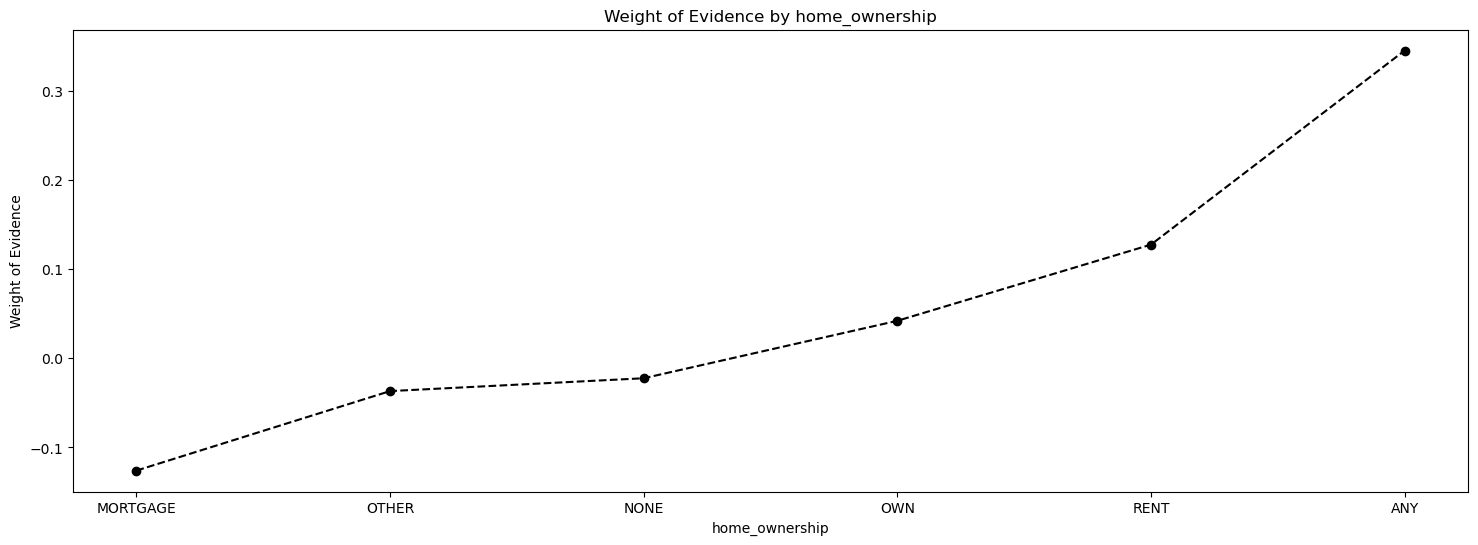


verification_status: IV = 0.0376
  verification_status  n_obs  prop_good       WoE
0        Not Verified  64984   0.151884 -0.275967
1     Source Verified  50956   0.203627  0.080151
2            Verified  68696   0.218470  0.169313


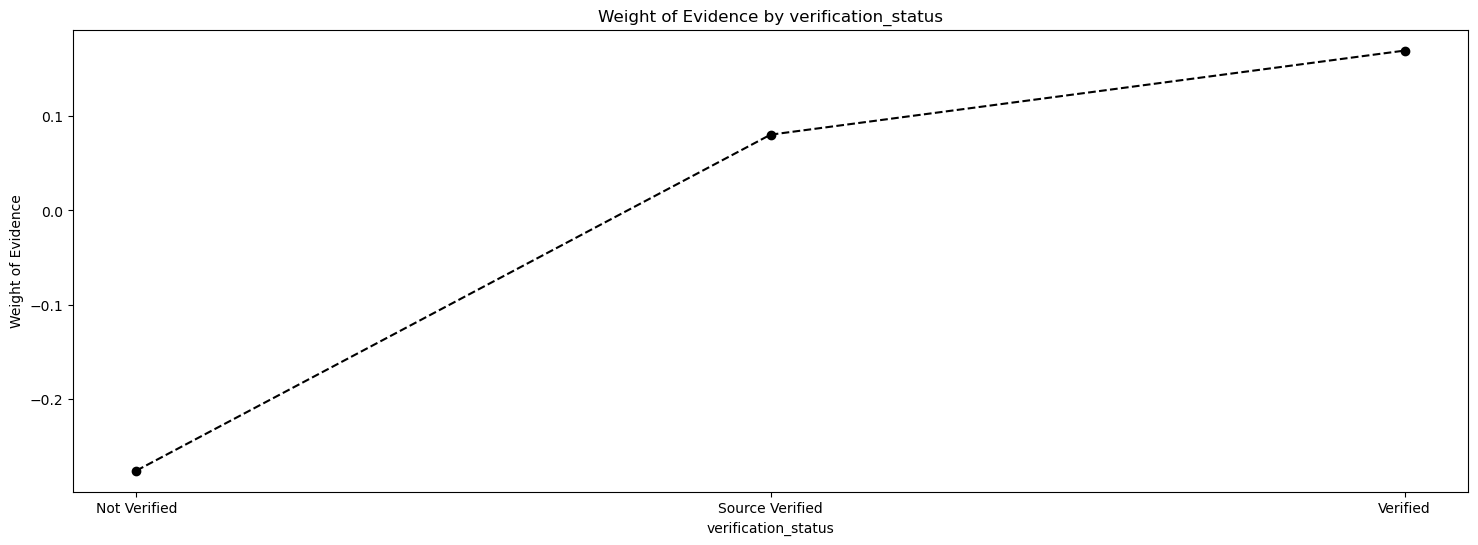


purpose: IV = 0.0275
               purpose   n_obs  prop_good       WoE
0                  car    2820   0.124823 -0.502539
1              wedding    1621   0.139420 -0.374487
2       major_purchase    4684   0.144535 -0.333737
3          credit_card   36908   0.164815 -0.178986
4     home_improvement   10761   0.165319 -0.175170
5     renewable_energy     194   0.185567 -0.024666
6             vacation    1135   0.189427 -0.008180
7          educational     343   0.192420  0.015157
8                house    1205   0.195021  0.027676
9   debt_consolidation  106995   0.199383  0.053640
10             medical    2084   0.212572  0.135108
11               other   10645   0.221043  0.184328
12              moving    1495   0.221405  0.187357
13      small_business    3746   0.300320  0.598257


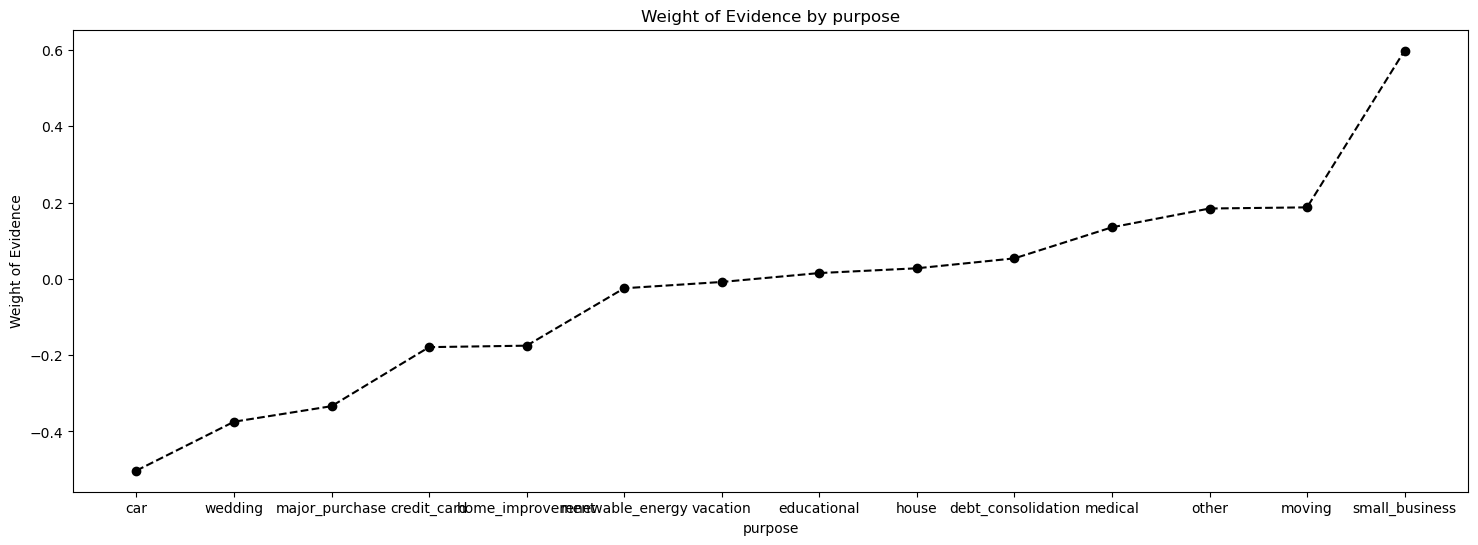

In [33]:
for col in ['home_ownership', 'verification_status', 'purpose']:
    df_temp = woe_discrete(X_train, col, y_train)
    print(f"\n{col}: IV = {df_temp['IV'].iloc[0]:.4f}")
    print(df_temp[[col, 'n_obs', 'prop_good', 'WoE']])
    plot_by_woe(df_temp)

In [34]:
# ============================================================
# ## PURPOSE: Create grouped dummy variables based on WoE bins
# ============================================================

# ------------------------------------------------------------
# ## Step 1: Create dummy variables for 'purpose'
# ------------------------------------------------------------
X_train = pd.get_dummies(X_train, columns=['purpose'])
X_test  = pd.get_dummies(X_test,  columns=['purpose'])

# Ensure train and test have identical columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Rename dummy columns to scorecard style: purpose:category
rename_map = {col: col.replace('purpose_', 'purpose:')
              for col in X_train.columns if col.startswith('purpose_')}

X_train.rename(columns=rename_map, inplace=True)
X_test.rename(columns=rename_map, inplace=True)


# ------------------------------------------------------------
# ## Step 2: Define purpose groups based on WoE similarity
# ------------------------------------------------------------
purpose_groups = {
    
    'purpose:high_risk': [
        'purpose:car',
        'purpose:wedding',
        'purpose:major_purchase'
    ],

    'purpose:above_avg_risk': [
        'purpose:credit_card',
        'purpose:home_improvement'
    ],

    'purpose:average': [
        'purpose:renewable_energy',
        'purpose:vacation',
        'purpose:educational',
        'purpose:house',
        'purpose:debt_consolidation'
    ],

    'purpose:low_risk': [
        'purpose:medical',
        'purpose:other',
        'purpose:moving'
    ]
}


# ------------------------------------------------------------
# ## Step 3: Create grouped dummy variables
# ------------------------------------------------------------
for new_col, cols in purpose_groups.items():
    
    X_train[new_col] = X_train[cols].sum(axis=1)
    X_test[new_col]  = X_test[cols].sum(axis=1)


# ------------------------------------------------------------
# ## Step 4: Keep 'small_business' as separate bin
# ------------------------------------------------------------
X_train['purpose:small_business'] = X_train['purpose:small_business']
X_test['purpose:small_business']  = X_test['purpose:small_business']


# ------------------------------------------------------------
# ## Step 5: Sanity check – every row should belong to one group
# ------------------------------------------------------------
p_cols = [
    'purpose:high_risk',
    'purpose:above_avg_risk',
    'purpose:average',
    'purpose:low_risk',
    'purpose:small_business'
]

print("Purpose — rows accounted for:", X_train[p_cols].sum().sum())
print("Total rows in X_train:      ", len(X_train))

# Optional stronger check
print("\nRow assignment check:")
print(X_train[p_cols].sum(axis=1).value_counts())

Purpose — rows accounted for: 184636
Total rows in X_train:       184636

Row assignment check:
1    184636
Name: count, dtype: int64


In [35]:
# ── HOME OWNERSHIP ───────────────────────────────────────────────

# Get dummies first
X_train = pd.get_dummies(X_train, columns=['home_ownership'])
X_test  = pd.get_dummies(X_test,  columns=['home_ownership'])
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

# Rename underscores to colons
rename_map = {col: col.replace('home_ownership_', 'home_ownership:')
              for col in X_train.columns if col.startswith('home_ownership_')}
X_train = X_train.rename(columns=rename_map)
X_test  = X_test.rename(columns=rename_map)

# Group 1: higher risk (WoE < -0.08)
# MORTGAGE is clearly the riskiest
X_train['home_ownership:MORTGAGE'] = X_train['home_ownership:MORTGAGE']
X_test['home_ownership:MORTGAGE']  = X_test['home_ownership:MORTGAGE']

# Group 2: average risk — NONE, OTHER, OWN all clustered near zero
X_train['home_ownership:NONE_OTHER_OWN'] = sum([X_train['home_ownership:NONE'],
                                                 X_train['home_ownership:OTHER'],
                                                 X_train['home_ownership:OWN']])
X_test['home_ownership:NONE_OTHER_OWN']  = sum([X_test['home_ownership:NONE'],
                                                 X_test['home_ownership:OTHER'],
                                                 X_test['home_ownership:OWN']])

# Group 3: lower risk — RENT + ANY (ANY has 1 obs, absorb into RENT)
X_train['home_ownership:RENT_ANY'] = sum([X_train['home_ownership:RENT'],
                                           X_train['home_ownership:ANY']])
X_test['home_ownership:RENT_ANY']  = sum([X_test['home_ownership:RENT'],
                                           X_test['home_ownership:ANY']])

# Sanity check
ho_cols = ['home_ownership:MORTGAGE', 'home_ownership:NONE_OTHER_OWN', 'home_ownership:RENT_ANY']
print("home_ownership — rows accounted for:", X_train[ho_cols].sum().sum())
print("Total rows in X_train:              ", len(X_train))

home_ownership — rows accounted for: 184636
Total rows in X_train:               184636


In [36]:
# ── VERIFICATION STATUS ──────────────────────────────────────────

# Only 3 categories, all clearly separated on WoE — no grouping needed
# Not Verified (-0.276), Source Verified (0.080), Verified (0.169)
# Just create dummies directly

X_train = pd.get_dummies(X_train, columns=['verification_status'])
X_test  = pd.get_dummies(X_test,  columns=['verification_status'])
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

rename_map = {col: col.replace('verification_status_', 'verification_status:')
              for col in X_train.columns if col.startswith('verification_status_')}
X_train = X_train.rename(columns=rename_map)
X_test  = X_test.rename(columns=rename_map)

# Fix spaces in column names — get_dummies keeps spaces
X_train = X_train.rename(columns={
    'verification_status:Not Verified':    'verification_status:Not_Verified',
    'verification_status:Source Verified': 'verification_status:Source_Verified'
})
X_test = X_test.rename(columns={
    'verification_status:Not Verified':    'verification_status:Not_Verified',
    'verification_status:Source Verified': 'verification_status:Source_Verified'
})

# Sanity check
vs_cols = ['verification_status:Not_Verified',
           'verification_status:Source_Verified',
           'verification_status:Verified']
print("verification_status — rows accounted for:", X_train[vs_cols].sum().sum())
print("Total rows in X_train:                   ", len(X_train))

verification_status — rows accounted for: 184636
Total rows in X_train:                    184636


## Feature Engineering: Grouping of Discrete Variables

Based on the WoE analysis, categories with similar risk profiles were grouped to improve model stability and reduce dimensionality.

Grouping was performed for:
- addr_state
- purpose
- home_ownership
- verification status

Each observation was assigned to exactly one risk group, verified through sanity checks.

## Removing Individual Dummy Variables After Grouping

After performing WoE analysis, several categorical variables were grouped based on similar risk profiles (WoE values). These grouped variables were created to reduce dimensionality and improve model stability.

At this stage, the original individual dummy variables generated by `pd.get_dummies()` are no longer needed because:

1. **Grouped variables already capture the information contained in the individual categories.**
2. Keeping both the original dummy variables and the grouped variables would introduce **perfect multicollinearity** in the design matrix.
3. Multicollinearity can cause instability in logistic regression coefficients and reduce model interpretability.
4. Dropping the redundant dummy variables helps **preserve the rank of the feature matrix**, ensuring that the regression model can be estimated correctly.

Therefore, we remove the individual dummy variables and retain only the grouped risk-based variables created earlier.

The following variables are preserved:

- `addr_state`: grouped into risk-based state clusters  
- `home_ownership`: grouped based on WoE similarity  
- `purpose`: grouped into risk-based borrowing categories  
- `verification_status`: kept as-is since no grouping was required  

After this cleanup step, the dataset contains only the engineered grouped variables that will be used in the subsequent modeling stage.

In [37]:
# Drop all individual dummy columns — keep only the grouped ones

# addr_state individual dummies
addr_state_individual = [col for col in X_train.columns 
                         if col.startswith('addr_state:') 
                         and col not in ['addr_state:very_risky', 
                                         'addr_state:below_avg',
                                         'addr_state:average', 
                                         'addr_state:low_risk']]

# home_ownership individual dummies
home_ownership_individual = [col for col in X_train.columns
                              if col.startswith('home_ownership:')
                              and col not in ['home_ownership:MORTGAGE',
                                              'home_ownership:NONE_OTHER_OWN',
                                              'home_ownership:RENT_ANY']]

# purpose individual dummies
purpose_individual = [col for col in X_train.columns
                      if col.startswith('purpose:')
                      and col not in ['purpose:high_risk',
                                      'purpose:above_avg_risk',
                                      'purpose:average',
                                      'purpose:low_risk',
                                      'purpose:small_business']]

# verification_status — no grouping was done, all 3 kept as-is, nothing to drop

cols_to_drop = addr_state_individual + home_ownership_individual + purpose_individual

X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print("Columns dropped:", len(cols_to_drop))
print("X_train shape after cleanup:", X_train.shape)
print("X_test shape after cleanup: ", X_test.shape)

Columns dropped: 18
X_train shape after cleanup: (184636, 103)
X_test shape after cleanup:  (46159, 103)


In [38]:
# After all dummification, no object columns should remain
remaining_object_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Remaining object columns:", remaining_object_cols)

# sub_grade is still object — it's the one categorical variable we haven't processed yet
# That's expected and correct — it goes through WoE binning for continuous-style processing next

Remaining object columns: ['sub_grade', 'initial_list_status']


In [39]:
# Drop initial_list_status — IV = 0.001, useless predictor, never processed
X_train = X_train.drop(columns=['initial_list_status'])
X_test  = X_test.drop(columns=['initial_list_status'])

# Confirm only sub_grade remains as object
print("Remaining object columns:", X_train.select_dtypes(include='object').columns.tolist())
print("X_train shape:", X_train.shape)

Remaining object columns: ['sub_grade']
X_train shape: (184636, 102)


   sub_grade  n_obs  prop_good       WoE
0         A1   4378   0.032206 -1.955880
1         A2   4538   0.048480 -1.531217
2         A3   5327   0.056505 -1.370161
3         A4   8240   0.072937 -1.098112
4         A5   8694   0.088797 -0.884281
5         B1   8963   0.106438 -0.683647
6         B2  10966   0.117728 -0.570244
7         B3  13605   0.129364 -0.462802
8         B4  12617   0.144805 -0.332169
9         B5  10464   0.162366 -0.196941
10        C1  10863   0.177759 -0.087851
11        C2  10297   0.188987 -0.012860
12        C3   9112   0.221247  0.185310
13        C4   8528   0.231121  0.241734
14        C5   7985   0.244834  0.317365
15        D1   7250   0.252966  0.360871
16        D2   6677   0.265838  0.427885
17        D3   5817   0.268867  0.443373
18        D4   5318   0.303686  0.613915
19        D5   4393   0.307762  0.633153
20        E1   3305   0.321331  0.696136
21        E3   2668   0.350075  0.825086
22        E2   3236   0.358467  0.861716
23        G4    

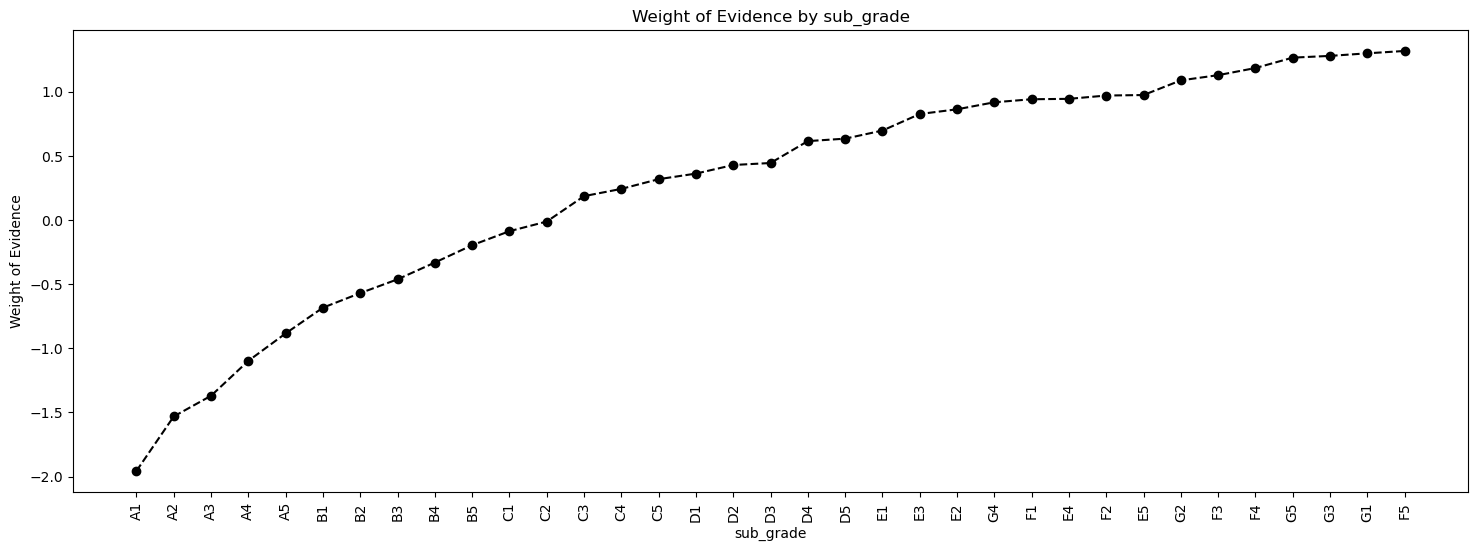

In [40]:
df_temp = woe_discrete(X_train, 'sub_grade', y_train)
print(df_temp[['sub_grade', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=90)

### Sub_grade 
is special compared to the others because it's 
already perfectly ordered — A1 is the safest, G5 is the riskiest.


In [41]:
# Dummify sub_grade — keep all individual categories
X_train = pd.get_dummies(X_train, columns=['sub_grade'])
X_test  = pd.get_dummies(X_test,  columns=['sub_grade'])
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

# Rename to colon convention
rename_map = {col: col.replace('sub_grade_', 'sub_grade:')
              for col in X_train.columns if col.startswith('sub_grade_')}
X_train = X_train.rename(columns=rename_map)
X_test  = X_test.rename(columns=rename_map)

# Sanity check
sg_cols = [col for col in X_train.columns if col.startswith('sub_grade:')]
print(f"Number of sub_grade dummies:    {len(sg_cols)}")
print(f"Rows accounted for:             {X_train[sg_cols].sum().sum()}")
print(f"Total rows in X_train:          {len(X_train)}")
print(f"\nRemaining object columns:       {X_train.select_dtypes(include='object').columns.tolist()}")
print(f"Final X_train shape:            {X_train.shape}")

Number of sub_grade dummies:    35
Rows accounted for:             184636
Total rows in X_train:          184636

Remaining object columns:       []
Final X_train shape:            (184636, 136)


In [42]:
# Preview what continuous variables are waiting
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical columns remaining: {len(num_cols)}")
print(num_cols)

Numerical columns remaining: 39
['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'term_month', 'emp_length_years', 'months_since_earliest_cr_line', 'months_since_issue_date', 'mths_since_last_delinq_missing', 'annual_inc_missing', 'emp_length_missing', 'mths_since_last_record_missing', 'mths_since_last_major_derog_missing', 'tot_cur_bal_missing', 'total_rev_hi_lim_missing', 'tot_coll_amt_missing', 'purpose:high_risk', 'purpose:above_avg_risk', 'purpose:average', 'purpose:low_risk']


## WoE Binning for Continuous Variables

After completing feature engineering for categorical variables, we proceed to transform continuous numerical variables using Weight of Evidence (WoE) binning.

Continuous variables are first divided into quantile-based bins using `pd.qcut`. For each bin, the distribution of good and bad observations is calculated, allowing the computation of WoE values.

This process helps:

- Capture non-linear relationships between predictors and default risk
- Reduce the impact of outliers
- Improve model interpretability
- Ensure monotonic relationships between risk and predictor variables

The resulting WoE-transformed variables will be used as inputs for the logistic regression PD model.

In [43]:
def woe_ordered_continuous(df, continuous_variable_name, good_bad_variable_df, n_bins=10):
    
    df = pd.concat([df[continuous_variable_name], good_bad_variable_df], axis=1)
    
    df['Bins'] = pd.qcut(df[continuous_variable_name], n_bins, duplicates='drop')
    
    df = pd.concat([
        df.groupby('Bins', as_index=False, observed=True)[good_bad_variable_df.name].count(),
        df.groupby('Bins', as_index=False, observed=True)[good_bad_variable_df.name].mean()
    ], axis=1)
    
    df = df.iloc[:, [0, 1, 3]]
    df.columns = ['Bins', 'n_obs', 'prop_good']
    
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad']  = (1 - df['prop_good']) * df['n_obs']
    
    n_bins = len(df)
    df['prop_n_good'] = (df['n_good'] + 0.5) / (df['n_good'].sum() + 0.5 * n_bins)
    df['prop_n_bad']  = (df['n_bad']  + 0.5) / (df['n_bad'].sum()  + 0.5 * n_bins)
    
    
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    
    df['diff_prop_good'] = df['prop_n_good'].diff().abs()
    df['diff_WoE']       = df['WoE'].diff().abs()
    
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    
    return df

In [44]:
# Same plot_by_woe function — redefined here for notebook readability
# so this section is self-contained when run independently

def plot_by_woe(df_woe, rotation_of_x_axis_labels=0):
    x = np.array(df_woe.iloc[:, 0].apply(str))
    y = df_woe['WoE']
    plt.figure(figsize=(18, 6))
    plt.plot(x, y, marker='o', linestyle='--', color='k')
    plt.xlabel(str(df_woe.columns[0]))
    plt.ylabel('Weight of Evidence')
    plt.title('Weight of Evidence by ' + str(df_woe.columns[0]))
    plt.xticks(rotation=rotation_of_x_axis_labels)
    plt.show()

In [45]:
# Define continuous vars — exclude all dummies already created
continuous_vars = [
    col for col in X_train.columns
    if not col.startswith('sub_grade:')
    and not col.startswith('purpose:')
    and not col.startswith('home_ownership:')
    and not col.startswith('addr_state:')
    and not col.startswith('verification_status:')
    and X_train[col].dtype in ['int64', 'float64']
]

print(f"Continuous variables to process: {len(continuous_vars)}")
print(continuous_vars)

Continuous variables to process: 35
['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'term_month', 'emp_length_years', 'months_since_earliest_cr_line', 'months_since_issue_date', 'mths_since_last_delinq_missing', 'annual_inc_missing', 'emp_length_missing', 'mths_since_last_record_missing', 'mths_since_last_major_derog_missing', 'tot_cur_bal_missing', 'total_rev_hi_lim_missing', 'tot_coll_amt_missing']


In [46]:
# Collect IV for all continuous variables
iv_continuous = {}

for col in continuous_vars:
    try:
        df_temp = woe_ordered_continuous(X_train, col, y_train, n_bins=10)
        iv_continuous[col] = round(df_temp['IV'].iloc[0], 4)
    except Exception as e:
        iv_continuous[col] = None
        print(f"  ERROR on {col}: {e}")

# Print sorted by IV descending
iv_series = pd.Series(iv_continuous).sort_values(ascending=False)
print("\nIV Summary — Continuous Variables:")
print(iv_series.to_string())


IV Summary — Continuous Variables:
int_rate                               0.4064
dti                                    0.0843
revol_util                             0.0608
annual_inc                             0.0579
tot_cur_bal                            0.0370
funded_amnt                            0.0285
id                                     0.0284
loan_amnt                              0.0284
funded_amnt_inv                        0.0281
months_since_issue_date                0.0271
total_rev_hi_lim                       0.0250
installment                            0.0200
inq_last_6mths                         0.0171
months_since_earliest_cr_line          0.0116
emp_length_years                       0.0054
total_acc                              0.0053
revol_bal                              0.0045
mths_since_last_delinq                 0.0030
delinq_2yrs                            0.0018
open_acc                               0.0016
mths_since_last_major_derog            0.000

## Information Value (IV) Analysis for Continuous Variables

After computing Weight of Evidence (WoE) bins for the numerical variables, the Information Value (IV) of each variable is calculated. IV measures the predictive power of a variable in distinguishing between good and bad borrowers.

Typical IV interpretation:

| IV Range | Predictive Power |
|--------|----------------|
| < 0.02 | Weak predictor |
| 0.02 – 0.1 | Medium predictor |
| 0.1 – 0.3 | Strong predictor |
| > 0.3 | Very strong predictor |

### Key Observations

**Strong Predictor**

- **int_rate (IV ≈ 0.41)**  
  This is the strongest continuous predictor. Higher interest rates are typically assigned to borrowers with higher credit risk, making this variable highly informative.

**Medium Predictors**

These variables show meaningful predictive power and will be retained for WoE binning and further modeling:

- `dti`
- `revol_util`
- `annual_inc`
- `tot_cur_bal`
- `funded_amnt`
- `loan_amnt`
- `funded_amnt_inv`
- `months_since_issue_date`
- `total_rev_hi_lim`
- `installment`

**Weak Predictors**

Variables with IV below approximately **0.02** show limited predictive ability. These will be reviewed later and may be removed during feature selection.

Many of the `_missing` indicator variables also show **IV ≈ 0**, indicating that missingness itself does not contain predictive information for this dataset.

### Multicollinearity Consideration

Some variables represent closely related concepts and may introduce multicollinearity in the logistic regression model.

For example:

- `loan_amnt`
- `funded_amnt`
- `funded_amnt_inv`

These variables are highly correlated because they all represent variations of the loan amount. To reduce redundancy, **only one of these variables (typically `funded_amnt`) will be retained in the final model.**

### Special Case: `term_month`

The variable `term_month` has only two values (36 and 60 months). When attempting to apply quantile binning (`qcut`), the bins collapse due to the limited number of unique values, resulting in an IV close to zero.

Because of this, `term_month` will be handled as a **categorical variable** rather than a continuous variable.

---

In the next step, the WoE curves of the strongest variables will be inspected to ensure that the relationship between the predictor and default risk is **monotonic**, after which bins may be merged to create stable and interpretable groups.

In [47]:
# Drop only the truly zero or near-zero ones that binning cannot rescue
# and the clearly redundant ones
cols_to_drop_now = [
    'funded_amnt_inv',    # redundant with funded_amnt — not an IV issue
    'loan_amnt',          # redundant with funded_amnt — not an IV issue
    'tot_coll_amt',       # IV 0.0000
    'acc_now_delinq',     # IV 0.0000
    'collections_12_mths_ex_med',  # IV 0.0000
    # missing indicators — all 0.0000, binning cannot help binary columns
    'mths_since_last_delinq_missing',
    'annual_inc_missing',
    'emp_length_missing',
    'mths_since_last_record_missing',
    'mths_since_last_major_derog_missing',
    'tot_cur_bal_missing',
    'total_rev_hi_lim_missing',
    'tot_coll_amt_missing'
]

X_train = X_train.drop(columns=cols_to_drop_now)
X_test  = X_test.drop(columns=cols_to_drop_now)

print("X_train shape:", X_train.shape)

X_train shape: (184636, 123)


### Handle term_month as a Discrete Variable only two categories available 36 months and 60 months

   term_month   n_obs  prop_good       WoE
0          36  145288   0.157528 -0.232810
1          60   39348   0.314298  0.663827


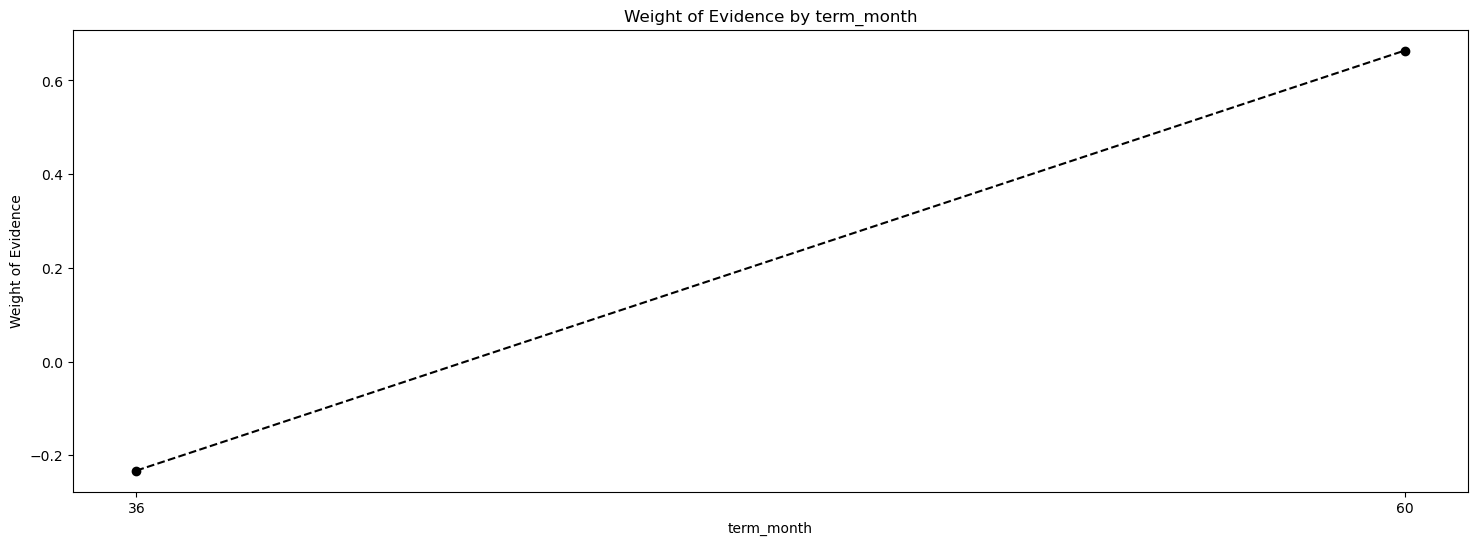

In [48]:
# Check WoE for term_month as discrete variable first
df_temp = woe_discrete(X_train, 'term_month', y_train)
print(df_temp[['term_month', 'n_obs', 'prop_good', 'WoE']])
plot_by_woe(df_temp)

In [49]:
# Convert to dummy — 60 months is the risky category, use it as the reference
X_train['term_month:60'] = (X_train['term_month'] == 60).astype(int)
X_test['term_month:60']  = (X_test['term_month'] == 60).astype(int)

# Drop original
X_train = X_train.drop(columns=['term_month'])
X_test  = X_test.drop(columns=['term_month'])

# Verify
print("term_month:60 value counts (train):")
print(X_train['term_month:60'].value_counts())
print("\nX_train shape:", X_train.shape)

term_month:60 value counts (train):
term_month:60
0    145288
1     39348
Name: count, dtype: int64

X_train shape: (184636, 123)


## Handling `term_month` as a Discrete Variable

The variable `term_month` represents the loan repayment period and contains only two possible values:

- **36 months**
- **60 months**

Because this variable has only two categories, applying quantile-based binning (`qcut`) is not appropriate. Instead, it is treated as a **discrete categorical variable**, and WoE is computed directly for the two categories.

### WoE Results

| term_month | WoE | Interpretation |
|------------|-----|---------------|
| 36 | -0.233 | Higher proportion of bad loans |
| 60 | 0.664 | Higher proportion of good loans |

### Interpretation

Weight of Evidence (WoE) measures the relative distribution of good and bad borrowers within each category.

- **Negative WoE** indicates that the category contains a **higher proportion of bad borrowers** compared to the overall population.
- **Positive WoE** indicates that the category contains a **higher proportion of good borrowers**.

Based on the data:

- **36-month loans show higher relative default risk**
- **60-month loans show lower relative default risk**

This may appear counterintuitive from a theoretical perspective, since longer loan terms are often assumed to be riskier. However, WoE reflects the **empirical distribution of the dataset** rather than assumptions. In this dataset, borrowers taking **60-month loans appear to perform better on average**, possibly due to borrower selection effects (for example, larger loans taken by higher-income borrowers).

### Encoding Strategy

To avoid multicollinearity in logistic regression, one category is selected as the **reference group**.

A single dummy variable is therefore created:

`term_month:60`


             Bins  n_obs  prop_good       WoE
0    (5.419, 7.9]  22879   0.056515 -1.370897
1     (7.9, 9.91]  14174   0.095950 -0.798906
2   (9.91, 11.14]  18410   0.116784 -0.579219
3  (11.14, 12.49]  19433   0.140894 -0.363909
4  (12.49, 13.65]  18119   0.166676 -0.165420
5  (13.65, 14.49]  18708   0.188422 -0.016368
6   (14.49, 15.8]  18761   0.220830  0.183072
7   (15.8, 17.57]  18983   0.265922  0.428471
8  (17.57, 19.52]  17361   0.297736  0.585774
9  (19.52, 26.06]  17808   0.382300  0.964051


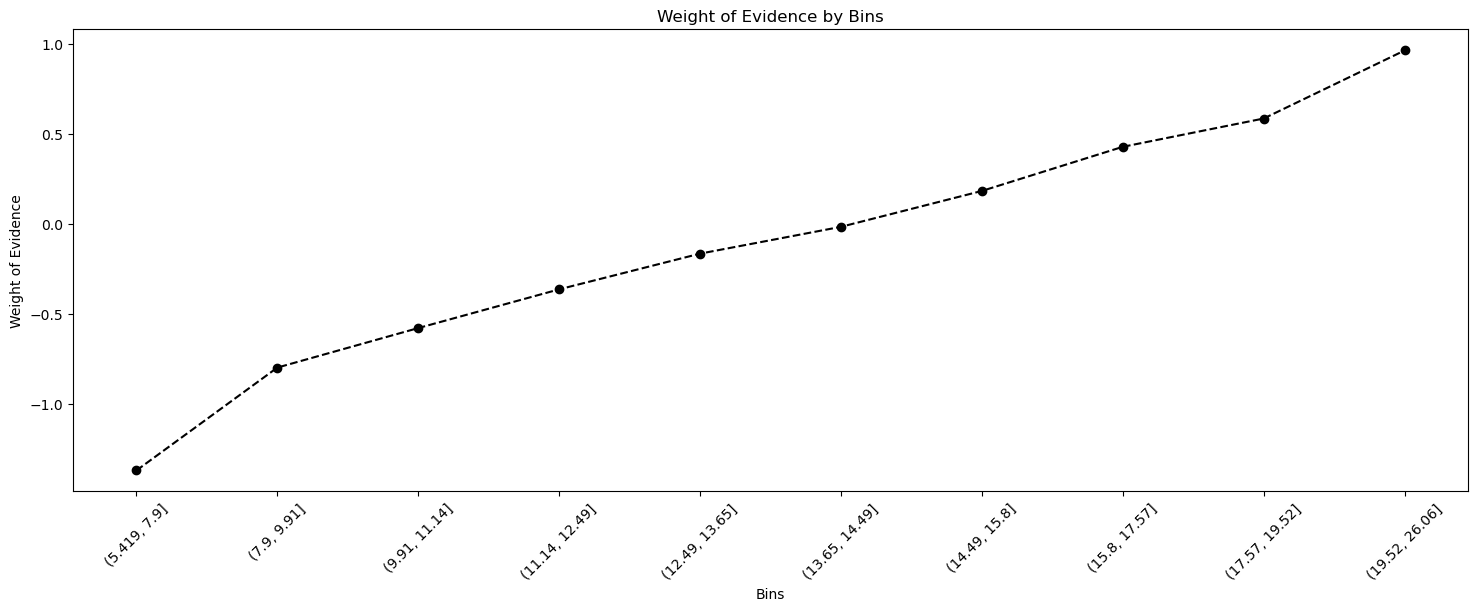

In [50]:
# ── INT_RATE ──────────────────────────────────────────────────────
# Strongest continuous predictor — IV 0.4065
# Higher interest rate = riskier borrower = expect monotonically increasing WoE

df_temp = woe_ordered_continuous(X_train, 'int_rate', y_train, n_bins=10)
print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=45)

              Bins  n_obs  prop_good       WoE
0   (-0.001, 6.35]  18508   0.133078 -0.430026
1     (6.35, 9.38]  18445   0.139930 -0.371894
2    (9.38, 11.79]  18464   0.156792 -0.238337
3   (11.79, 13.94]  18506   0.163947 -0.185198
4   (13.94, 16.05]  18465   0.174709 -0.108673
5    (16.05, 18.2]  18434   0.189107 -0.011893
6    (18.2, 20.51]  18426   0.204059  0.082805
7   (20.51, 23.15]  18468   0.221518  0.187067
8  (23.15, 26.775]  18456   0.240951  0.296426
9  (26.775, 39.99]  18464   0.285474  0.526410


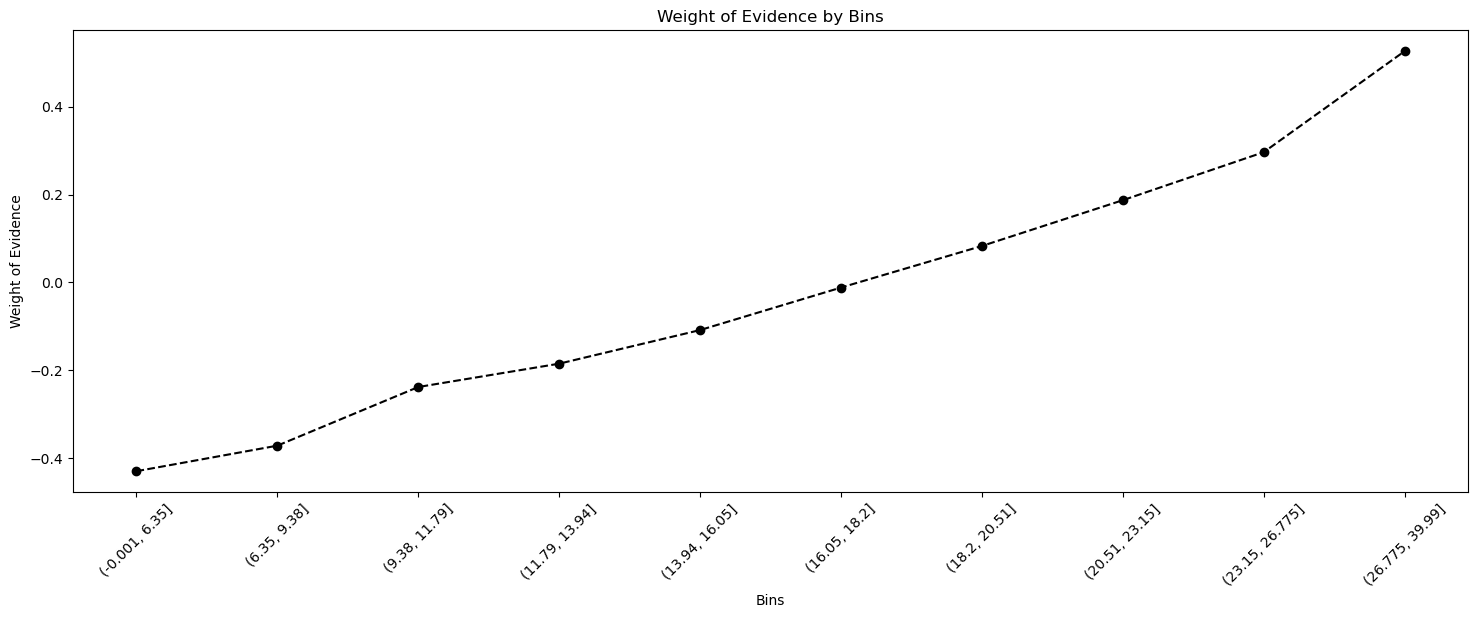

In [51]:
# ── DTI ───────────────────────────────────────────────────────────
# Debt-to-income ratio — IV 0.0843
# Higher DTI = more debt relative to income = expect increasing WoE

df_temp = woe_ordered_continuous(X_train, 'dti', y_train, n_bins=10)
print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=45)

             Bins  n_obs  prop_good       WoE
0  (-0.001, 19.6]  18494   0.118417 -0.563492
1    (19.6, 32.1]  18564   0.147005 -0.314316
2    (32.1, 41.3]  18404   0.165399 -0.174643
3    (41.3, 49.2]  18634   0.184126 -0.044709
4    (49.2, 56.4]  18281   0.190471 -0.003024
5    (56.4, 63.5]  18621   0.200473  0.060576
6    (63.5, 70.6]  18397   0.211882  0.130297
7    (70.6, 78.3]  18499   0.217471  0.163445
8    (78.3, 87.0]  18368   0.227189  0.219649
9   (87.0, 153.0]  18374   0.247687  0.332906


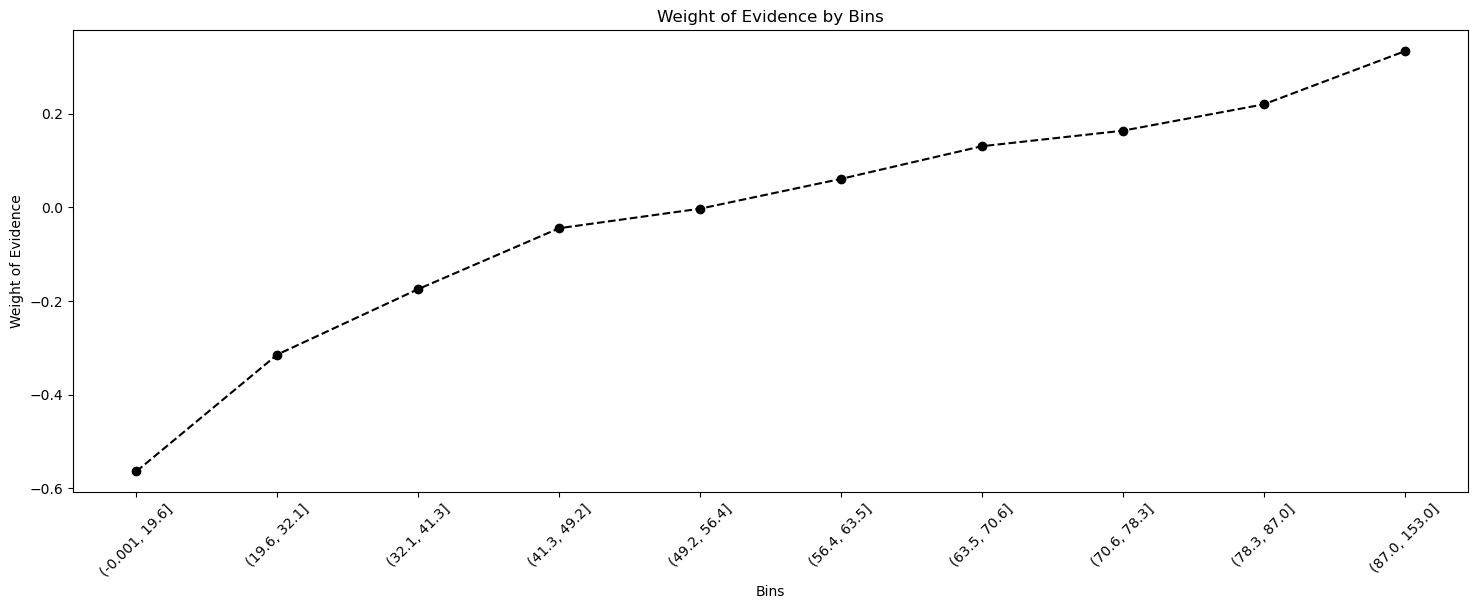

In [52]:
# ── REVOL_UTIL ────────────────────────────────────────────────────
# Revolving credit utilisation — IV 0.0608
# Higher utilisation = closer to credit limit = expect increasing WoE

df_temp = woe_ordered_continuous(X_train, 'revol_util', y_train, n_bins=10)
print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=45)

                   Bins  n_obs  prop_good       WoE
0  (17999.999, 33000.0]  18775   0.250493  0.347904
1    (33000.0, 40700.0]  18157   0.235722  0.267620
2    (40700.0, 48000.0]  19220   0.217482  0.163504
3    (48000.0, 55000.0]  20842   0.204971  0.088395
4    (55000.0, 62000.0]  16714   0.203542  0.079626
5    (62000.0, 70000.0]  18577   0.185606 -0.034888
6    (70000.0, 80000.0]  18498   0.172073 -0.127065
7    (80000.0, 95000.0]  18354   0.154353 -0.256894
8   (95000.0, 120000.0]  18967   0.145200 -0.328789
9  (120000.0, 235000.0]  16532   0.133015 -0.430550


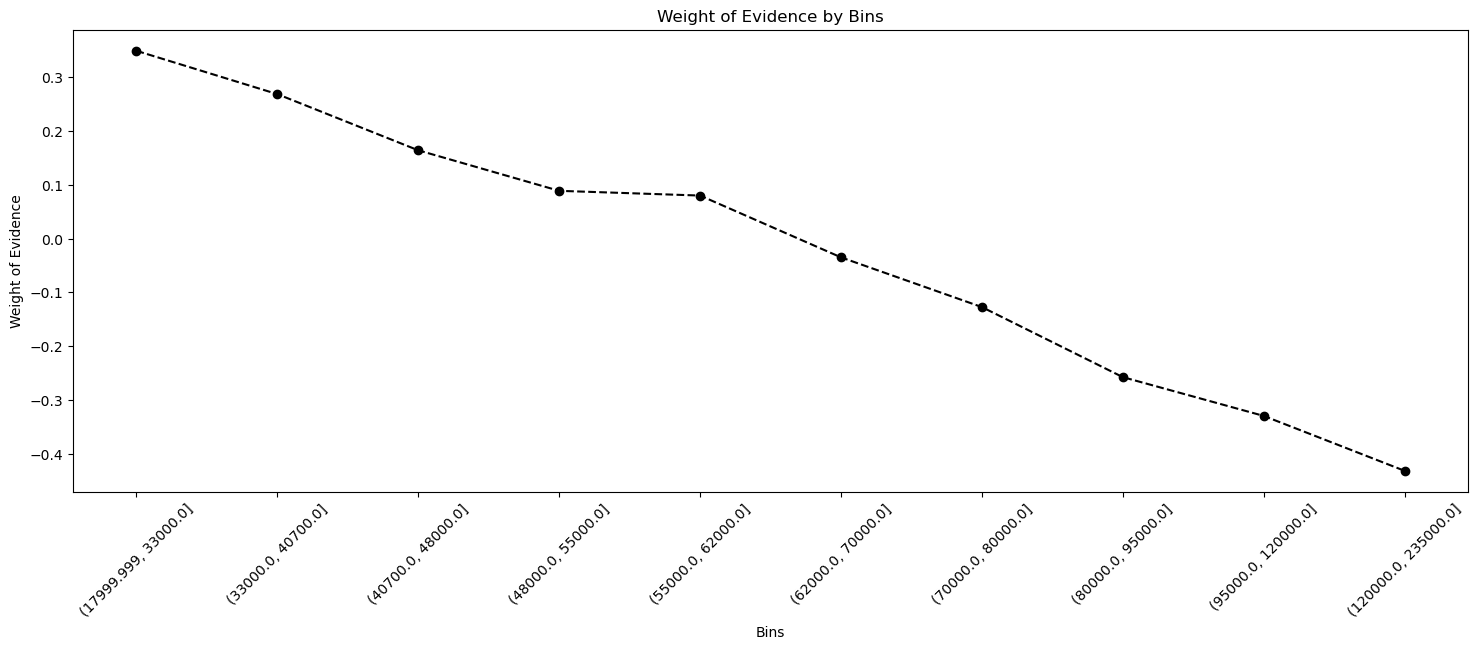

In [53]:
# ── ANNUAL_INC ────────────────────────────────────────────────────
# Annual income — IV 0.0579
# Higher income = lower default risk = expect decreasing WoE

df_temp = woe_ordered_continuous(X_train, 'annual_inc', y_train, n_bins=10)
print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=45)

                    Bins  n_obs  prop_good       WoE
0      (-0.001, 17446.5]  18464   0.218912  0.171915
1     (17446.5, 31296.0]  18466   0.230315  0.237391
2     (31296.0, 53741.5]  18461   0.234115  0.258703
3     (53741.5, 80282.0]  63482   0.172458 -0.124427
4    (80282.0, 121098.0]  10372   0.211724  0.129442
5   (121098.0, 190811.0]  18464   0.200932  0.063460
6   (190811.0, 285377.0]  18463   0.174403 -0.110775
7  (285377.0, 4772549.0]  18464   0.138811 -0.381199


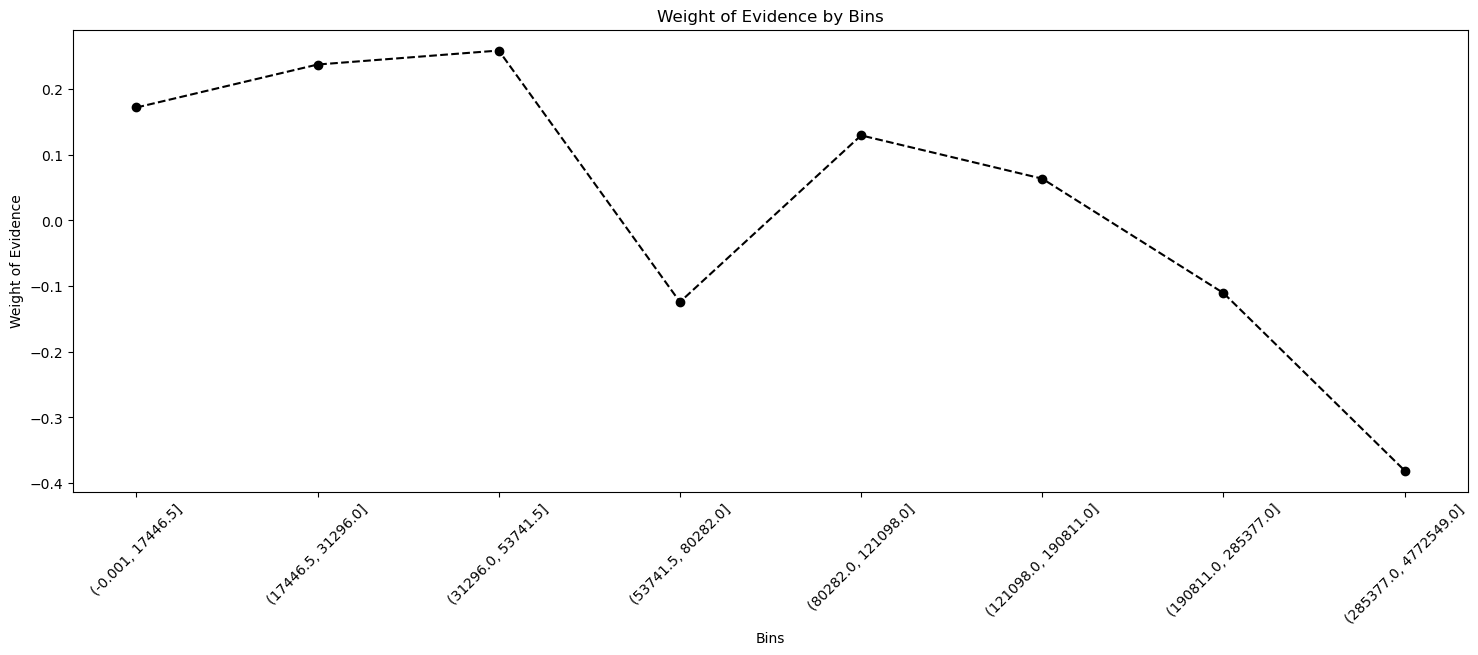

In [54]:
# ── TOT_CUR_BAL ───────────────────────────────────────────────────
# Total current balance across all accounts — IV 0.0370
# Higher balance may indicate more financial obligations
# Direction less clear — inspect the plot carefully

df_temp = woe_ordered_continuous(X_train, 'tot_cur_bal', y_train, n_bins=10)
print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=45)

                 Bins  n_obs  prop_good       WoE
0   (499.999, 4500.0]  18580   0.166469 -0.166911
1    (4500.0, 6000.0]  18518   0.160817 -0.208210
2    (6000.0, 8000.0]  19873   0.165903 -0.171002
3   (8000.0, 10000.0]  25584   0.178393 -0.083370
4  (10000.0, 12000.0]  19247   0.182782 -0.053684
5  (12000.0, 14000.0]   9892   0.181359 -0.063133
6  (14000.0, 16000.0]  18385   0.194670  0.023976
7  (16000.0, 20000.0]  22112   0.216805  0.159514
8  (20000.0, 25000.0]  16599   0.225496  0.209991
9  (25000.0, 35000.0]  15846   0.245740  0.322444


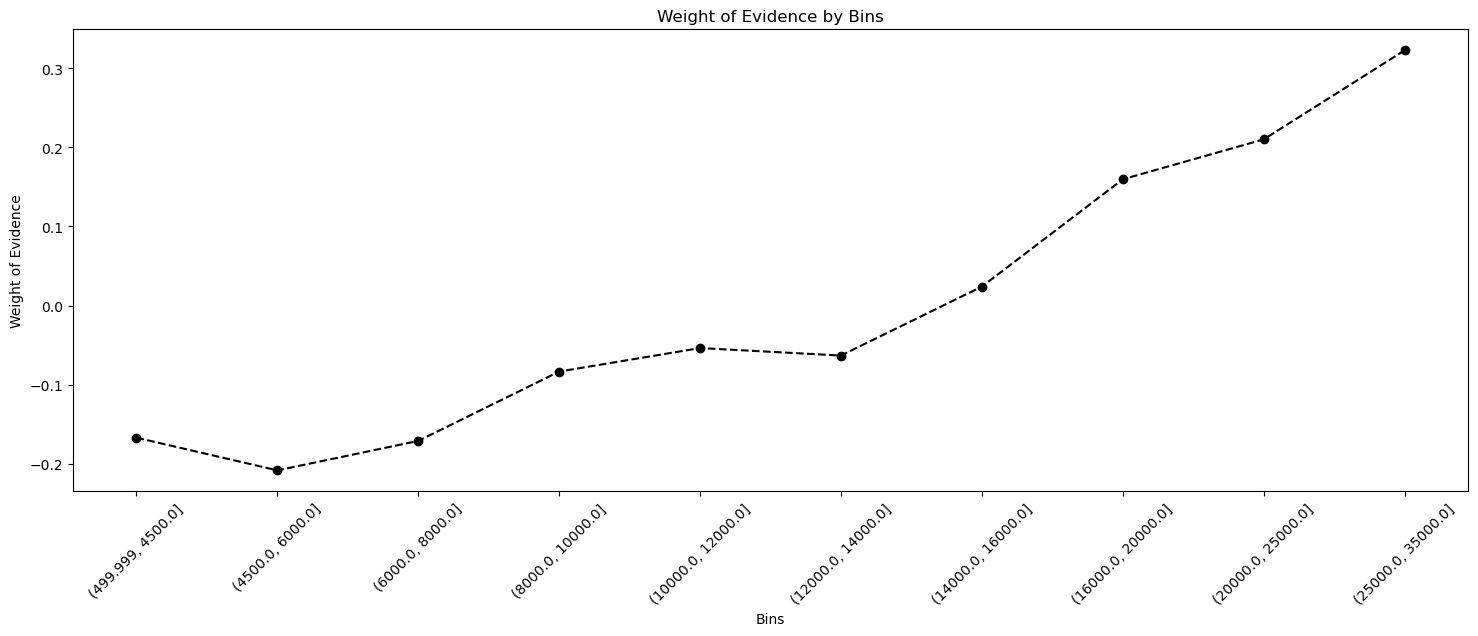

In [55]:
# ── FUNDED_AMNT ───────────────────────────────────────────────────
# Amount funded — IV 0.0285
# loan_amnt and funded_amnt_inv already dropped as redundant
# Larger loans may carry more risk but also go to better borrowers
# Inspect for monotonicity

df_temp = woe_ordered_continuous(X_train, 'funded_amnt', y_train, n_bins=10)
print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=45)

             Bins  n_obs  prop_good       WoE
0  (23.999, 28.0]  18714   0.203591  0.079917
1    (28.0, 32.0]  21755   0.215261  0.150396
2    (32.0, 36.0]  20224   0.206735  0.099186
3    (36.0, 39.0]  15804   0.209377  0.115248
4    (39.0, 43.0]  19689   0.220732  0.182498
5    (43.0, 47.0]  16404   0.202816  0.075148
6    (47.0, 51.0]  18278   0.154886 -0.252821
7    (51.0, 57.0]  17564   0.172056 -0.127172
8    (57.0, 70.0]  18499   0.166279 -0.168280
9   (70.0, 114.0]  17705   0.150748 -0.284770


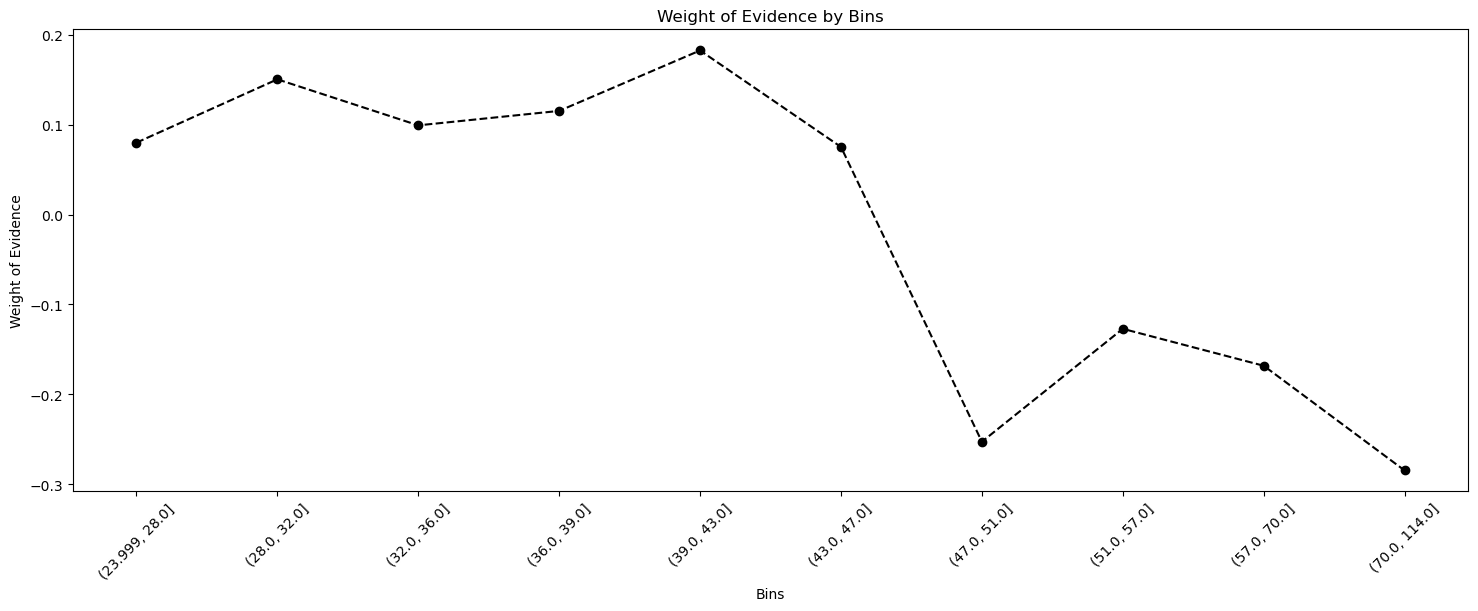

In [56]:
# ── MONTHS_SINCE_ISSUE_DATE ───────────────────────────────────────
# How many months since the loan was issued — IV 0.0271
# Older loans have had more time to resolve (pay off or default)
# More recent loans are more uncertain

df_temp = woe_ordered_continuous(X_train, 'months_since_issue_date', y_train, n_bins=10)
print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=45)

                   Bins  n_obs  prop_good       WoE
0      (-0.001, 9600.0]  18504   0.228653  0.227993
1     (9600.0, 14200.0]  18453   0.219531  0.175526
2    (14200.0, 19000.0]  18567   0.214628  0.146682
3    (19000.0, 22100.0]  63540   0.169909 -0.142396
4    (22100.0, 25700.0]  10355   0.204732  0.087039
5    (25700.0, 34000.0]  18418   0.202899  0.075670
6    (34000.0, 48700.0]  18361   0.190349 -0.003793
7  (48700.0, 2013133.0]  18438   0.153975 -0.259770


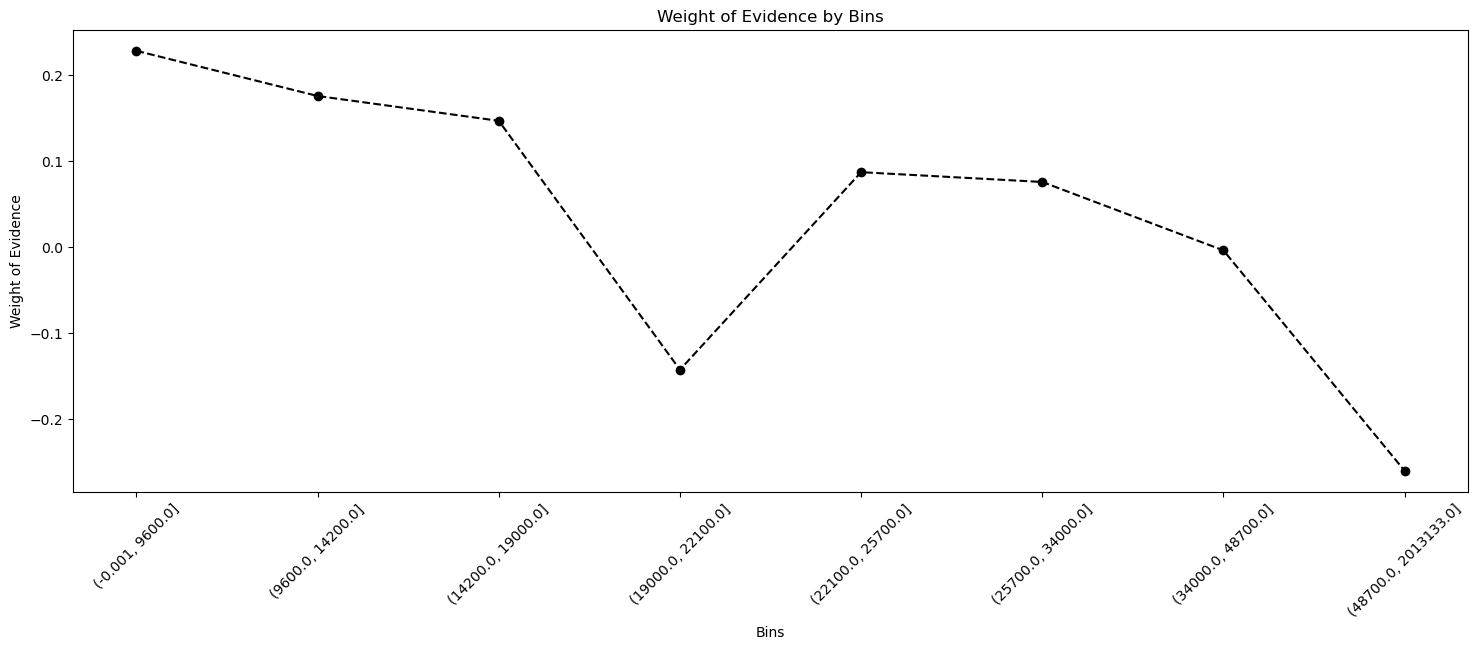

In [57]:
# ── TOTAL_REV_HI_LIM ──────────────────────────────────────────────
# Total revolving high credit limit — IV 0.0250
# Higher credit limit = better credit profile = expect decreasing WoE

df_temp = woe_ordered_continuous(X_train, 'total_rev_hi_lim', y_train, n_bins=10)
print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=45)

                 Bins  n_obs  prop_good       WoE
0    (51.259, 148.68]  18466   0.164898 -0.178278
1    (148.68, 205.54]  18484   0.159543 -0.217673
2    (205.54, 265.97]  18462   0.167317 -0.160817
3    (265.97, 318.72]  18443   0.186954 -0.025991
4    (318.72, 363.97]  18465   0.193068  0.013729
5    (363.97, 423.61]  18546   0.186671 -0.027857
6    (423.61, 500.65]  18525   0.202537  0.073407
7    (500.65, 600.07]  18319   0.230417  0.237942
8   (600.07, 751.525]  18462   0.199383  0.053763
9  (751.525, 1192.64]  18464   0.218912  0.171893


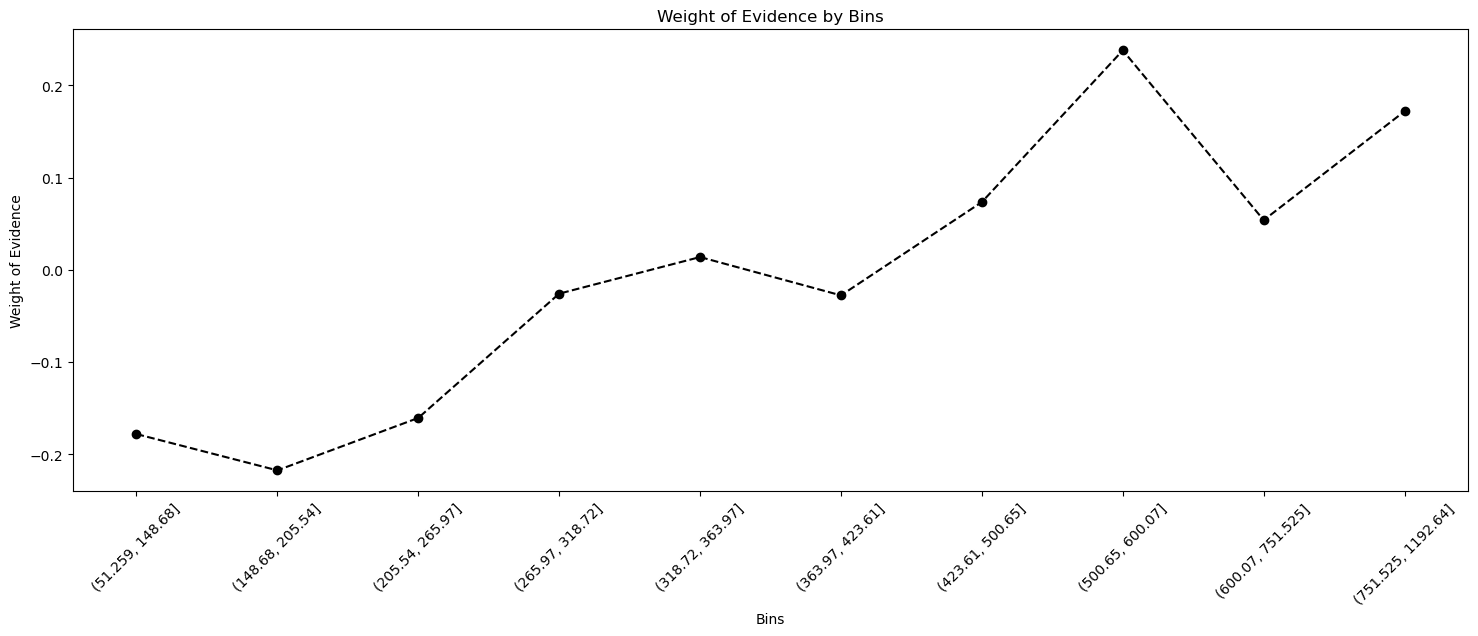

In [58]:
# ── INSTALLMENT ───────────────────────────────────────────────────
# Monthly payment amount — IV 0.0200
# Higher installment = larger loan burden
# Correlated with funded_amnt — watch for this in logistic regression later

df_temp = woe_ordered_continuous(X_train, 'installment', y_train, n_bins=10)
print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=45)

              Bins  n_obs  prop_good       WoE
0  (60.999, 134.0]  18570   0.232202  0.247984
1   (134.0, 160.0]  18616   0.198593  0.048807
2   (160.0, 181.0]  19166   0.201711  0.068284
3   (181.0, 196.0]  18598   0.191203  0.001717
4   (196.0, 211.0]  17421   0.192297  0.008778
5   (211.0, 230.0]  18489   0.186543 -0.028698
6   (230.0, 254.0]  18433   0.186079 -0.031758
7   (254.0, 284.0]  18458   0.172771 -0.122174
8   (284.0, 340.0]  18644   0.173246 -0.118852
9   (340.0, 851.0]  18241   0.174058 -0.113189


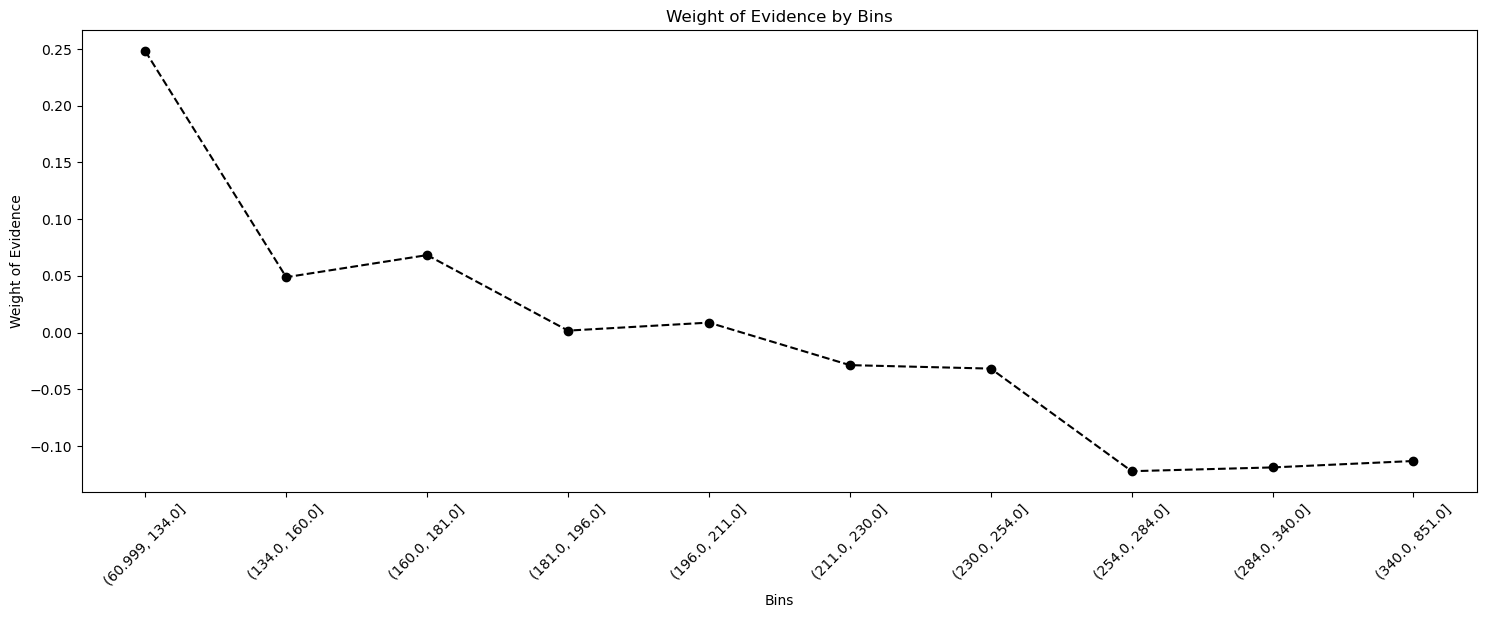

In [59]:
# ── MONTHS_SINCE_EARLIEST_CR_LINE ────────────────────────────────
# Length of credit history in months — IV 0.0116
# Longer credit history = more established borrower = expect decreasing WoE
# Borderline IV — keep for now, final decision after seeing bins

df_temp = woe_ordered_continuous(X_train, 'months_since_earliest_cr_line', y_train, n_bins=10)
print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
plot_by_woe(df_temp, rotation_of_x_axis_labels=45)


emp_length_years: IV = 0.0054
            Bins  n_obs  prop_good       WoE
0  (-0.001, 1.0]  27912   0.190921 -0.000121
1     (1.0, 2.0]  17440   0.181193 -0.064324
2     (2.0, 3.0]  14899   0.184442 -0.042556
3     (3.0, 5.0]  25368   0.182671 -0.054430
4     (5.0, 6.0]  18083   0.222861  0.194860
5     (6.0, 7.0]  10397   0.195345  0.028380
6     (7.0, 9.0]  15503   0.198413  0.047722
7    (9.0, 10.0]  55034   0.186176 -0.031174


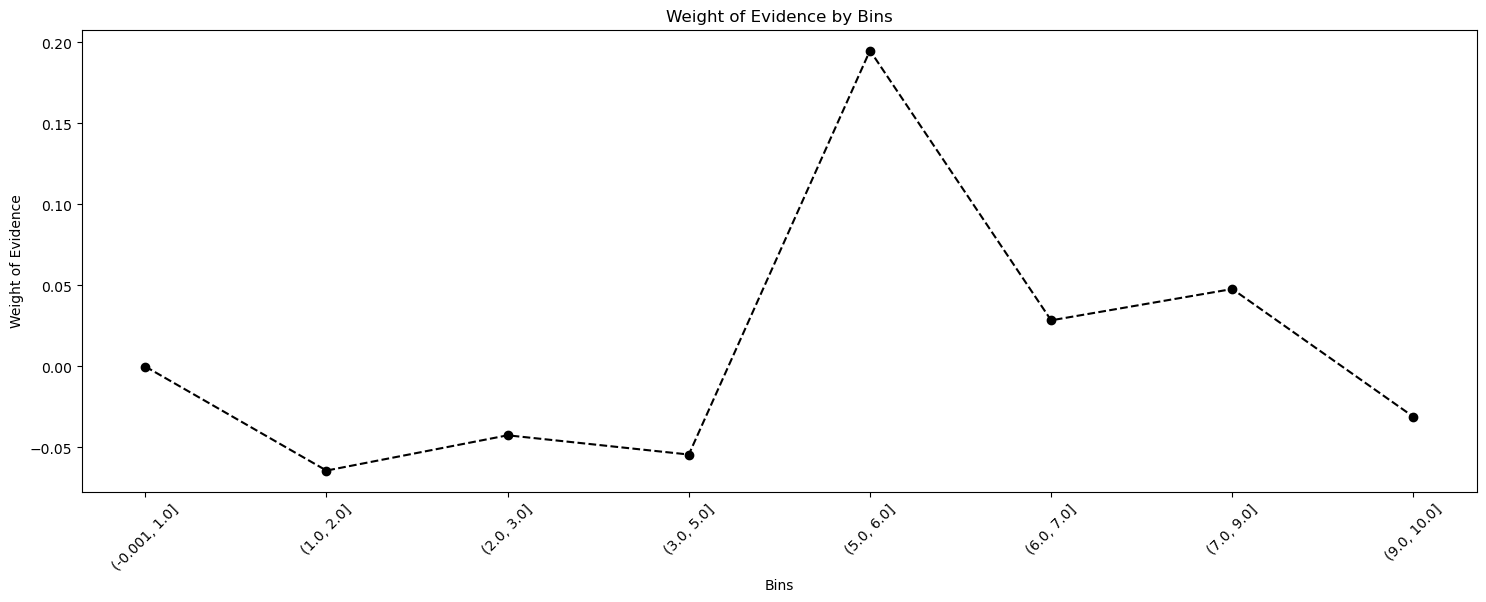


revol_bal: IV = 0.0045
                  Bins  n_obs  prop_good       WoE
0     (54.939, 2927.0]  18465   0.168698 -0.150939
1     (2927.0, 4968.0]  18468   0.180962 -0.065910
2     (4968.0, 6829.0]  18471   0.190190 -0.004848
3     (6829.0, 8788.0]  18451   0.192510  0.010143
4    (8788.0, 10980.0]  18469   0.193730  0.017973
5   (10980.0, 13579.0]  18458   0.197692  0.043141
6   (13579.0, 16938.0]  18466   0.204376  0.084750
7   (16938.0, 21778.0]  18462   0.201007  0.063911
8   (21778.0, 30344.5]  18462   0.198083  0.045601
9  (30344.5, 80631.22]  18464   0.182138 -0.057993


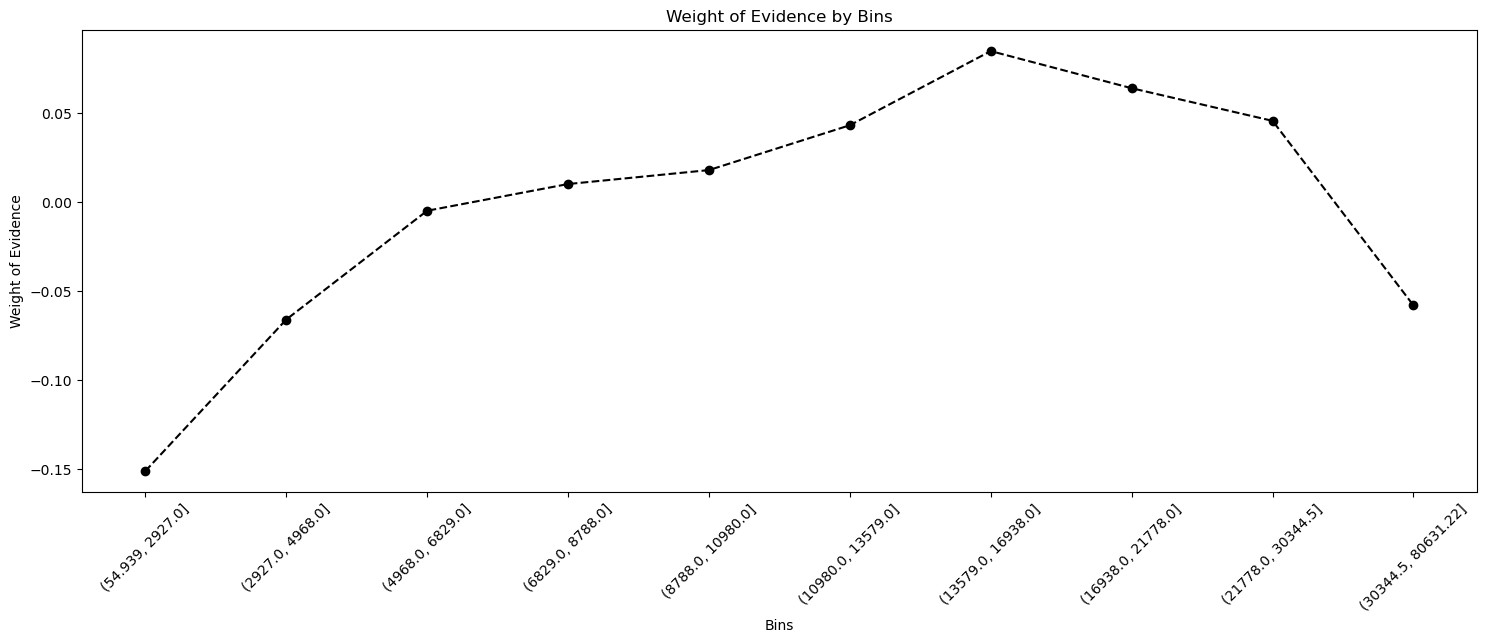


mths_since_last_delinq: IV = 0.003
             Bins   n_obs  prop_good       WoE
0  (-0.001, 15.0]   18774   0.215830  0.153831
1    (15.0, 29.0]   18419   0.191541  0.003956
2    (29.0, 45.0]   18491   0.183981 -0.045615
3    (45.0, 70.0]   18517   0.185505 -0.035499
4   (70.0, 999.0]  110435   0.188681 -0.014711


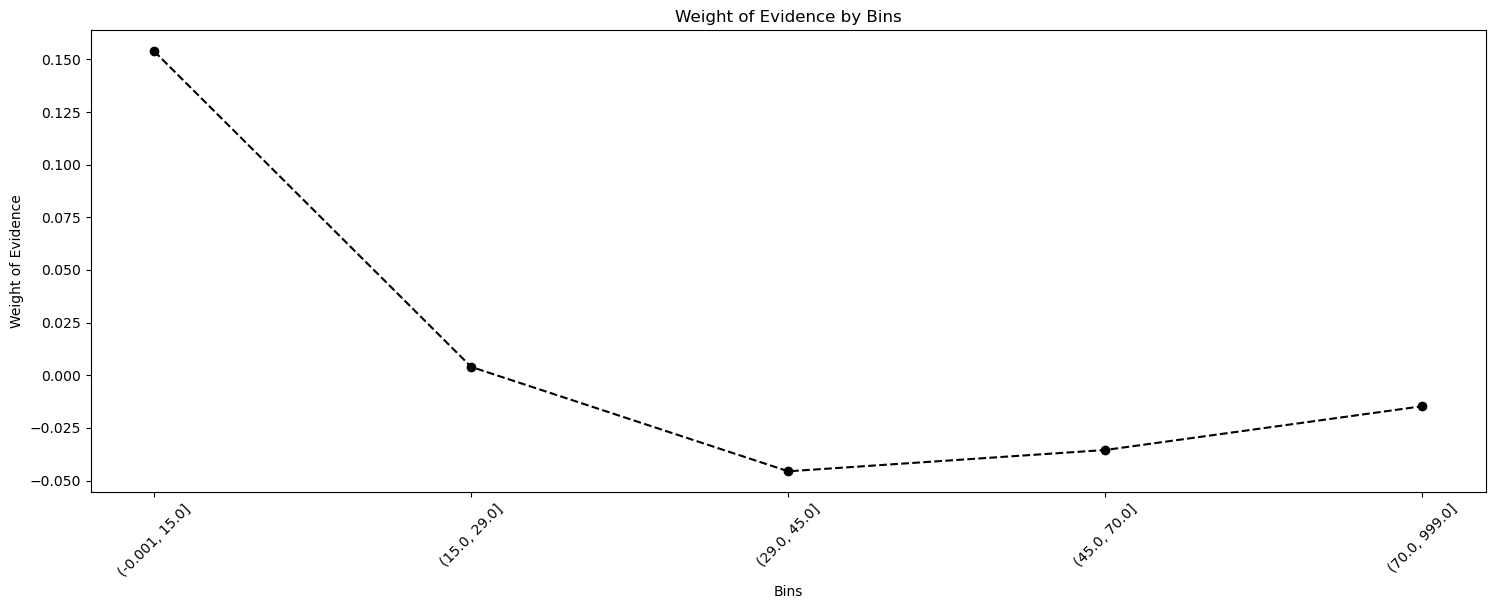


delinq_2yrs: IV = 0.0018
            Bins   n_obs  prop_good       WoE
0  (-0.001, 1.0]  175716   0.189408 -0.009944
1    (1.0, 19.0]    8920   0.221076  0.184682


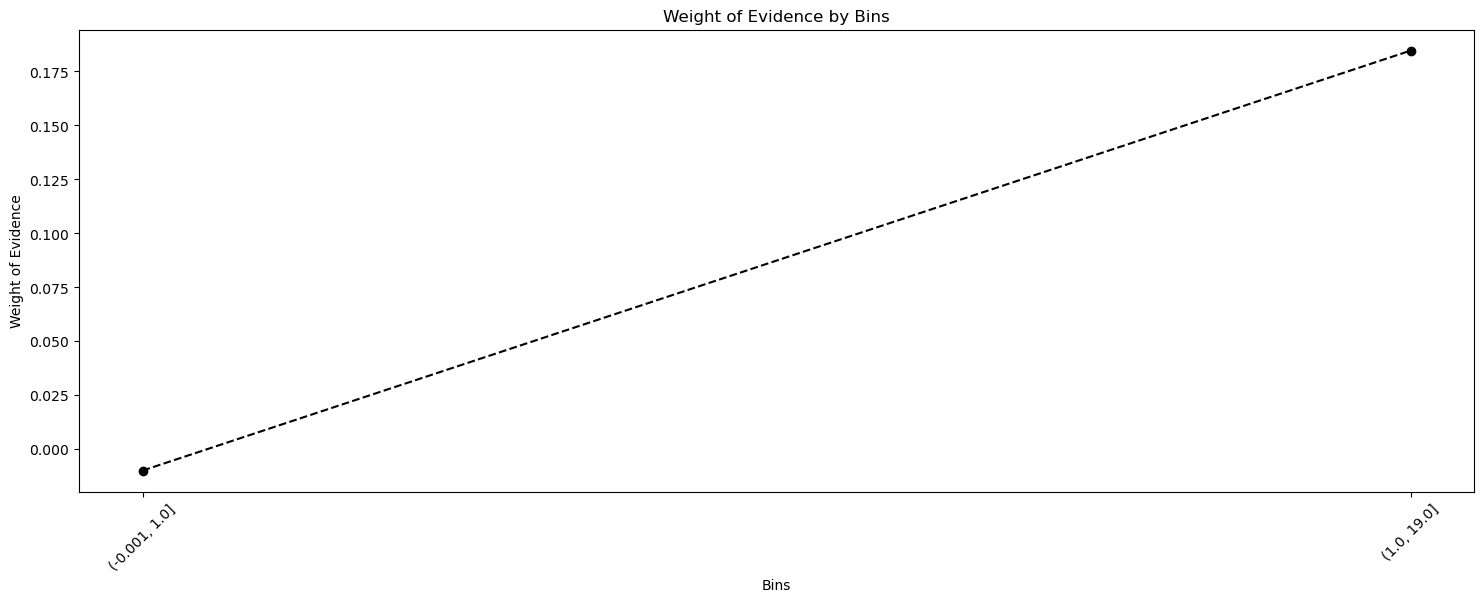


open_acc: IV = 0.0016
            Bins  n_obs  prop_good       WoE
0  (-0.001, 5.0]  18769   0.181576 -0.061773
1     (5.0, 7.0]  28822   0.183089 -0.051663
2     (7.0, 8.0]  17059   0.185943 -0.032650
3     (8.0, 9.0]  17808   0.189858 -0.006997
4    (9.0, 10.0]  16742   0.193406  0.015907
5   (10.0, 11.0]  15420   0.197276  0.040538
6   (11.0, 13.0]  24891   0.194448  0.022533
7   (13.0, 14.0]   9454   0.194944  0.025825
8   (14.0, 17.0]  18629   0.194321  0.021748
9   (17.0, 76.0]  17042   0.201443  0.066632


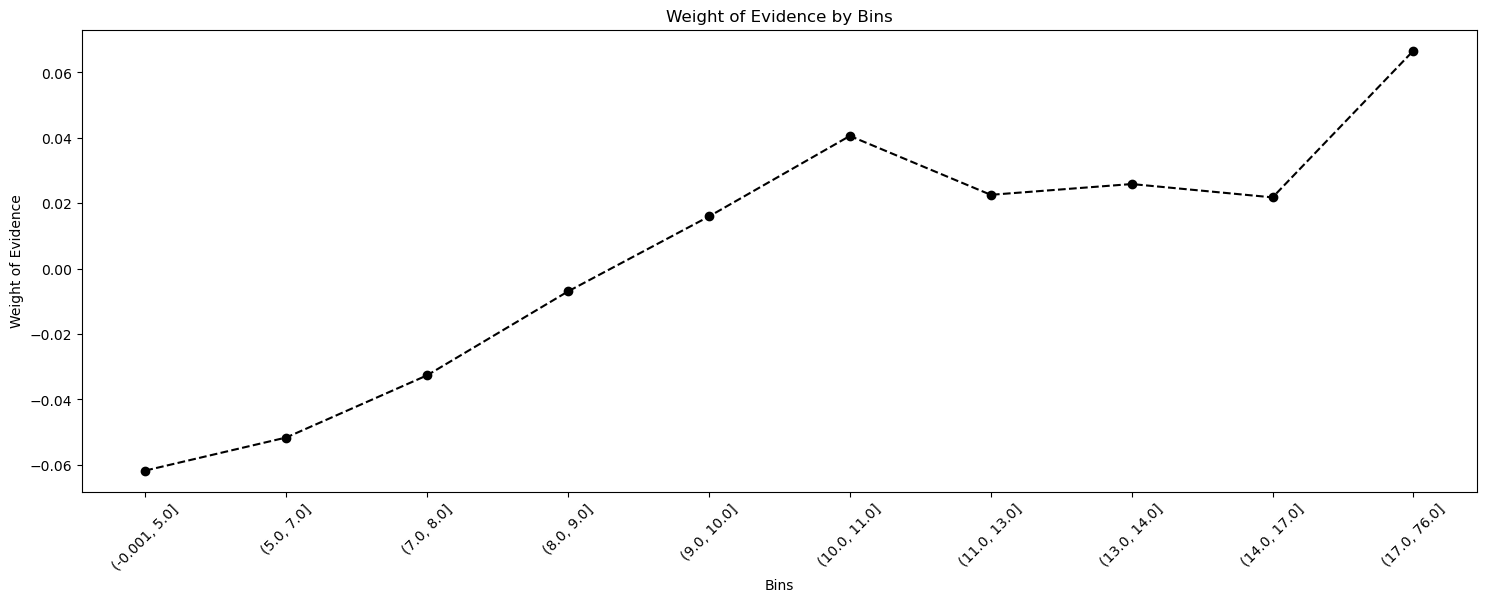


pub_rec: IV = 0.0005
            Bins   n_obs  prop_good       WoE
0  (-0.001, 1.0]  182333   0.190558 -0.002472
1    (1.0, 10.0]    2303   0.221016  0.184854


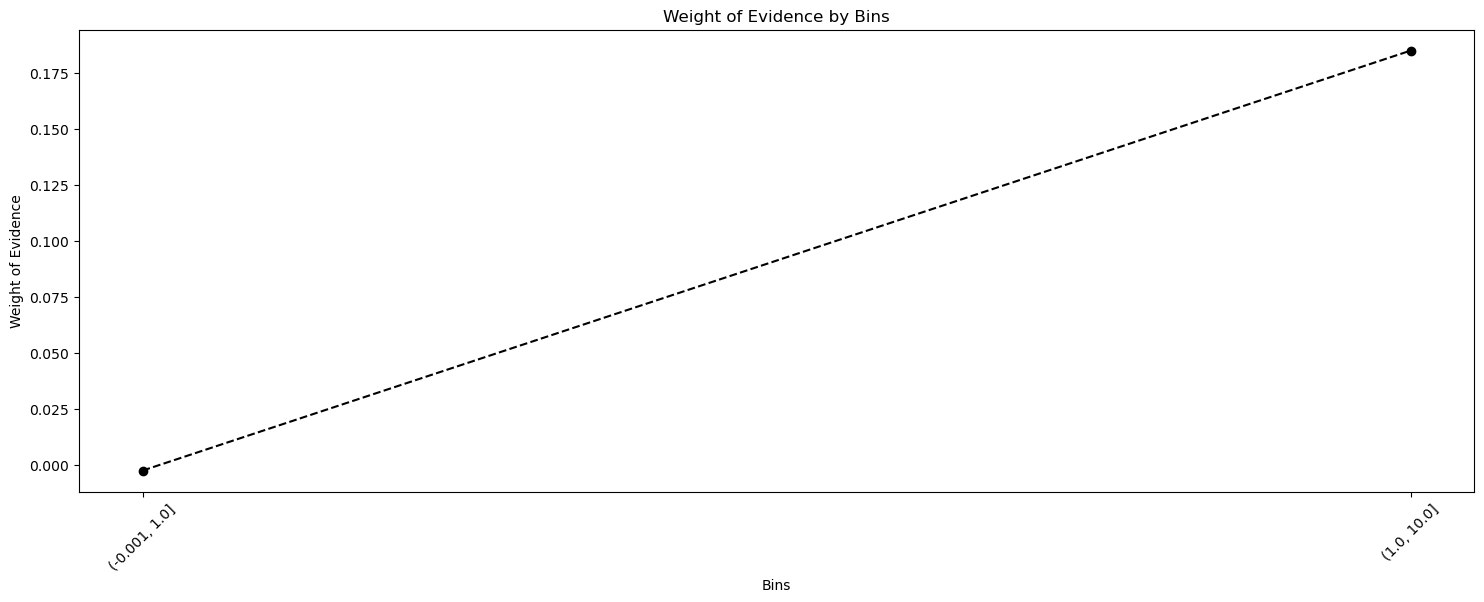


mths_since_last_major_derog: IV = 0.0007
             Bins   n_obs  prop_good       WoE
0  (-0.001, 47.0]   18816   0.202806  0.075156
1   (47.0, 999.0]  165820   0.189591 -0.008751


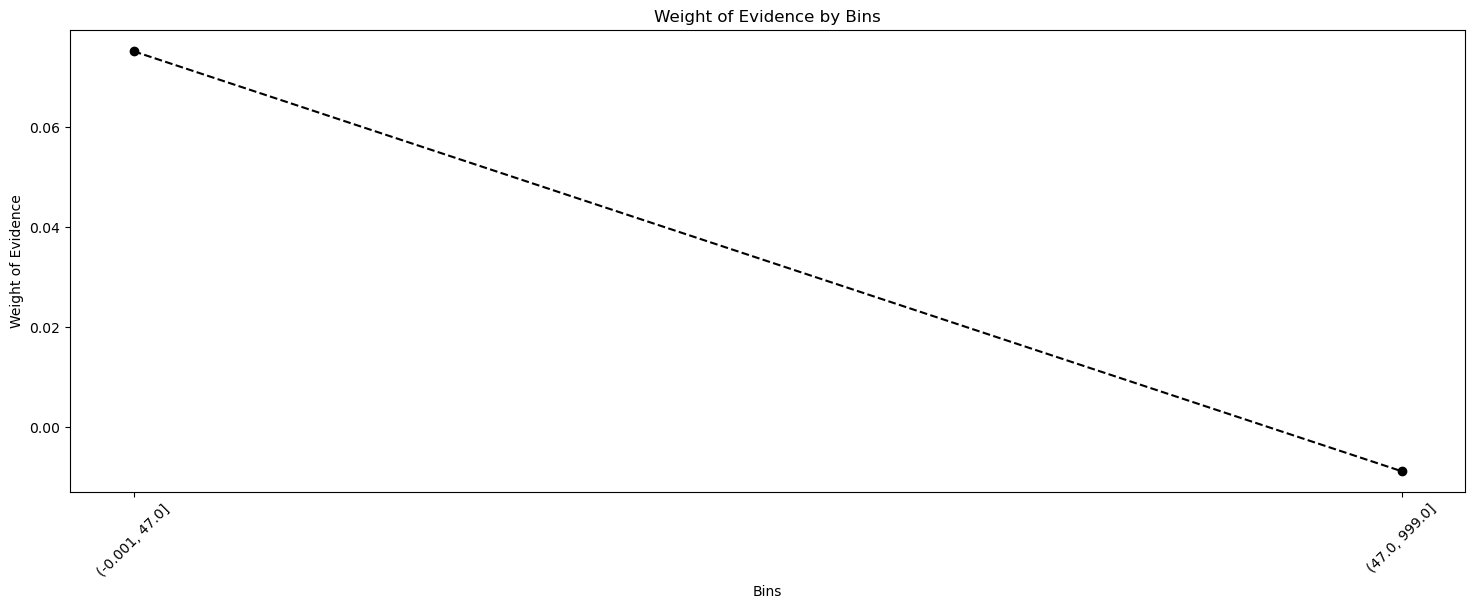


mths_since_last_record: IV = 0.0006
              Bins   n_obs  prop_good       WoE
0  (-0.001, 108.0]   18691   0.202290  0.071961
1   (108.0, 999.0]  165945   0.189659 -0.008308


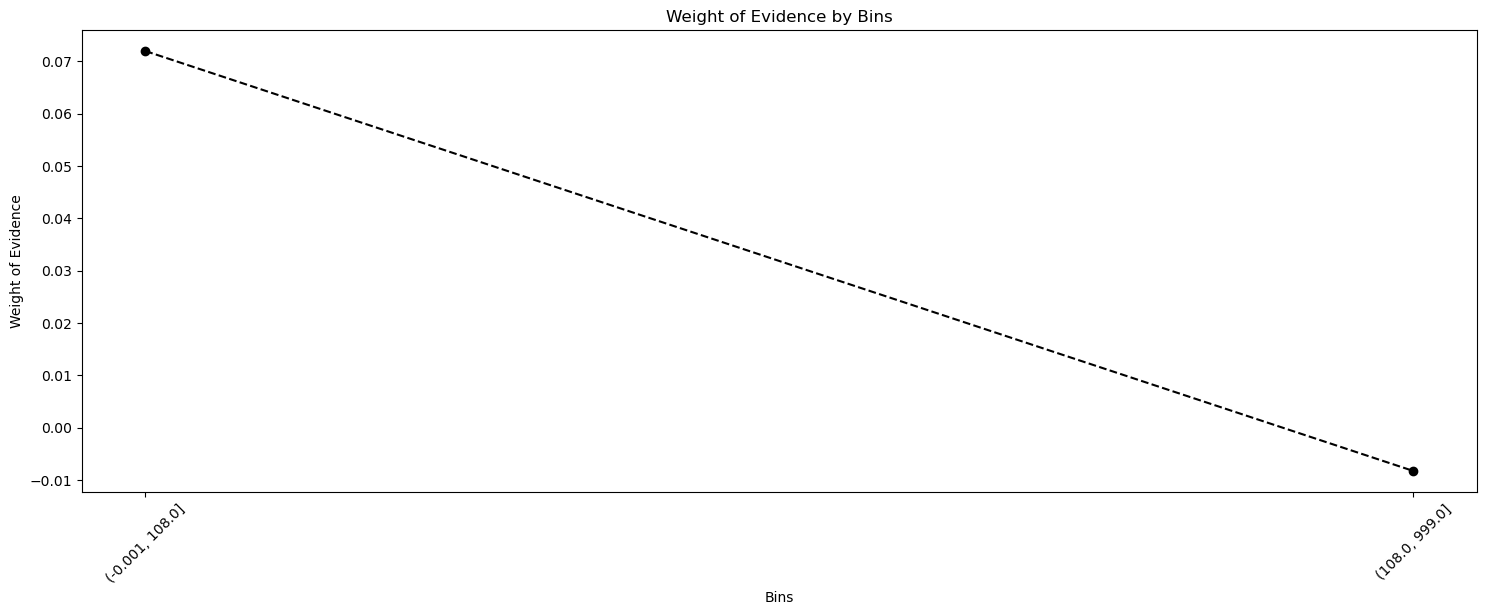

In [60]:
# ── VARIABLES TO REVIEW AFTER BINNING ────────────────────────────
# These had low IV on rough 10-bin pass but may improve with proper binning
# Run them and decide after seeing the plots

for col in ['emp_length_years', 'revol_bal', 'mths_since_last_delinq',
            'delinq_2yrs', 'open_acc', 'pub_rec',
            'mths_since_last_major_derog', 'mths_since_last_record']:
    try:
        df_temp = woe_ordered_continuous(X_train, col, y_train, n_bins=10)
        iv_val = round(df_temp['IV'].iloc[0], 4)
        print(f"\n{col}: IV = {iv_val}")
        print(df_temp[['Bins', 'n_obs', 'prop_good', 'WoE']].to_string())
        plot_by_woe(df_temp, rotation_of_x_axis_labels=45)
    except Exception as e:
        print(f"ERROR on {col}: {e}")

## WoE Binning — Continuous Variables: Observations and Next Steps

### Variables with Clean Monotonic WoE — Ready for Dummy Creation

**`int_rate`** — IV 0.4065 — Perfect monotonic increase. Lowest bin (5.4–7.9%) has WoE -1.37,
highest bin (19.5–26%) has WoE +0.96. No bin merging needed. This is the strongest
continuous predictor in the model.

**`dti`** — IV 0.0843 — Clean monotonic increase throughout. Low DTI borrowers
are safer (WoE -0.43), high DTI borrowers are riskier (WoE +0.53). No issues.

**`revol_util`** — IV 0.0608 — Broadly monotonic with a minor dip around bins 3–5
(WoE 0.044 → -0.006 → 0.060). These three middle bins are very close in WoE and
can be merged. Overall pattern is reliable.

**`annual_inc`** — IV 0.0579 — Mostly monotonic decrease (higher income = safer).
Small reversal between bins 6 and 7 (0.035 → 0.127 → 0.257). Bins 5–7 need merging.

---

### Variables with Non-Monotonic WoE — Require Bin Merging

**`tot_cur_bal`** — IV 0.0370 — Significantly non-monotonic. WoE jumps erratically
across bins. Only 8 bins produced (duplicates dropped). The relationship is U-shaped —
very low and very high balances both show different risk. Needs careful manual rebinning
using `pd.cut` with custom boundaries instead of `qcut`.

**`funded_amnt`** — IV 0.0285 — Non-monotonic. WoE dips negative in early bins then
rises. Instructor uses `pd.cut` with 50 fine-grained bins first to identify natural
breakpoints, then manually creates wider dummy bins.

**`months_since_issue_date`** — IV 0.0271 — Non-monotonic and erratic. Older loans
(higher months) should be more resolved, but pattern is inconsistent. Instructor
uses `np.where` with manual range boundaries after visual inspection.

**`total_rev_hi_lim`** — IV 0.0250 — Non-monotonic. Similar to `tot_cur_bal`,
the relationship is not linear. Needs custom bin boundaries.

**`installment`** — IV 0.0200 — Non-monotonic with a spike in the middle bins.
Correlated with `funded_amnt` — may be dropped after logistic regression p-value check.

**`inq_last_6mths`** — IV 0.0171 — Count variable with very uneven bin sizes.
Instructor treats this as near-discrete: 0, 1–2, 3–6, >6.

**`months_since_earliest_cr_line`** — IV 0.0116 — Non-monotonic. Broadly decreasing
(longer history = safer) but with reversals. Needs manual rebinning. Borderline IV —
final decision after proper binning.

---

### Low IV Variables — Decision Pending Proper Binning

| Variable | Rough IV | Pattern | Decision |
|---|---|---|---|
| `emp_length_years` | 0.0054 | Flat, no clear pattern | Likely drop |
| `revol_bal` | 0.0045 | Flat | Likely drop |
| `mths_since_last_delinq` | 0.0030 | Flat | Likely drop |
| `delinq_2yrs` | 0.0018 | Flat | Likely drop |
| `open_acc` | 0.0016 | Flat | Likely drop |
| `mths_since_last_major_derog` | 0.0007 | Flat | Drop |
| `mths_since_last_record` | 0.0006 | Flat | Drop |
| `pub_rec` | 0.0005 | Flat | Drop |

These will **not improve meaningfully with rebinning**. The flat WoE pattern means
the variable genuinely has no discriminatory power in this dataset, regardless of
how the bins are drawn. Final drop decision confirmed after p-value screening in
logistic regression.

---


## Continuous Variable Transformation — Dummy Binning

Continuous variables are transformed into **discrete risk bins** based on inspection of their WoE plots.

Instead of directly using the continuous values, we create **dummy variables for each bin** using manually selected boundaries. Each bin represents a range of the variable and becomes a separate 0/1 indicator column.

This approach is standard in credit scorecard modeling because it:

- Captures **non-linear relationships** between predictors and default risk
- Produces **interpretable risk segments**
- Ensures **stable logistic regression coefficients**
- Allows straightforward **scorecard scaling later**

The bin boundaries are chosen by visually inspecting the WoE plots to ensure a **monotonic relationship between the predictor and risk**.

For each continuous variable:

1. Manual boundaries are defined based on WoE patterns.
2. Dummy variables are created using `np.where`.
3. The same boundaries are applied to both **training and test datasets**.
4. The original continuous variable is **dropped after bin creation**.

These dummy variables will be used as the inputs for the **Logistic Regression PD model in the next notebook**.

In [61]:
# ── INT_RATE ─────────────────────────────────────────────────────
# Perfect monotonic — 5 clean bins based on natural WoE breakpoints

X_train['int_rate:<9.548']       = np.where(X_train['int_rate'] <= 9.548, 1, 0)
X_train['int_rate:9.548-12.025'] = np.where((X_train['int_rate'] > 9.548)  & (X_train['int_rate'] <= 12.025), 1, 0)
X_train['int_rate:12.025-15.74'] = np.where((X_train['int_rate'] > 12.025) & (X_train['int_rate'] <= 15.74),  1, 0)
X_train['int_rate:15.74-20.281'] = np.where((X_train['int_rate'] > 15.74)  & (X_train['int_rate'] <= 20.281), 1, 0)
X_train['int_rate:>20.281']      = np.where(X_train['int_rate'] > 20.281, 1, 0)

X_test['int_rate:<9.548']        = np.where(X_test['int_rate'] <= 9.548, 1, 0)
X_test['int_rate:9.548-12.025']  = np.where((X_test['int_rate'] > 9.548)  & (X_test['int_rate'] <= 12.025), 1, 0)
X_test['int_rate:12.025-15.74']  = np.where((X_test['int_rate'] > 12.025) & (X_test['int_rate'] <= 15.74),  1, 0)
X_test['int_rate:15.74-20.281']  = np.where((X_test['int_rate'] > 15.74)  & (X_test['int_rate'] <= 20.281), 1, 0)
X_test['int_rate:>20.281']       = np.where(X_test['int_rate'] > 20.281, 1, 0)

X_train = X_train.drop(columns=['int_rate'])
X_test  = X_test.drop(columns=['int_rate'])

print("int_rate sanity check:", X_train[['int_rate:<9.548','int_rate:9.548-12.025',
    'int_rate:12.025-15.74','int_rate:15.74-20.281','int_rate:>20.281']].sum().sum(), 
    "== ", len(X_train))

int_rate sanity check: 184636 ==  184636


In [62]:
# ── DTI ──────────────────────────────────────────────────────────
# Clean monotonic — 10 bins, boundaries from qcut output
# Instructor uses pd.cut(dti,100) to refine, then clips at 35 for outliers

X_train['dti:<=1.4']      = np.where(X_train['dti'] <= 1.4, 1, 0)
X_train['dti:1.4-3.5']    = np.where((X_train['dti'] > 1.4)  & (X_train['dti'] <= 3.5),  1, 0)
X_train['dti:3.5-7.7']    = np.where((X_train['dti'] > 3.5)  & (X_train['dti'] <= 7.7),  1, 0)
X_train['dti:7.7-10.5']   = np.where((X_train['dti'] > 7.7)  & (X_train['dti'] <= 10.5), 1, 0)
X_train['dti:10.5-16.1']  = np.where((X_train['dti'] > 10.5) & (X_train['dti'] <= 16.1), 1, 0)
X_train['dti:16.1-20.3']  = np.where((X_train['dti'] > 16.1) & (X_train['dti'] <= 20.3), 1, 0)
X_train['dti:20.3-21.7']  = np.where((X_train['dti'] > 20.3) & (X_train['dti'] <= 21.7), 1, 0)
X_train['dti:21.7-22.4']  = np.where((X_train['dti'] > 21.7) & (X_train['dti'] <= 22.4), 1, 0)
X_train['dti:22.4-35']    = np.where((X_train['dti'] > 22.4) & (X_train['dti'] <= 35),   1, 0)
X_train['dti:>35']        = np.where(X_train['dti'] > 35, 1, 0)

X_test['dti:<=1.4']       = np.where(X_test['dti'] <= 1.4, 1, 0)
X_test['dti:1.4-3.5']     = np.where((X_test['dti'] > 1.4)  & (X_test['dti'] <= 3.5),  1, 0)
X_test['dti:3.5-7.7']     = np.where((X_test['dti'] > 3.5)  & (X_test['dti'] <= 7.7),  1, 0)
X_test['dti:7.7-10.5']    = np.where((X_test['dti'] > 7.7)  & (X_test['dti'] <= 10.5), 1, 0)
X_test['dti:10.5-16.1']   = np.where((X_test['dti'] > 10.5) & (X_test['dti'] <= 16.1), 1, 0)
X_test['dti:16.1-20.3']   = np.where((X_test['dti'] > 16.1) & (X_test['dti'] <= 20.3), 1, 0)
X_test['dti:20.3-21.7']   = np.where((X_test['dti'] > 20.3) & (X_test['dti'] <= 21.7), 1, 0)
X_test['dti:21.7-22.4']   = np.where((X_test['dti'] > 21.7) & (X_test['dti'] <= 22.4), 1, 0)
X_test['dti:22.4-35']     = np.where((X_test['dti'] > 22.4) & (X_test['dti'] <= 35),   1, 0)
X_test['dti:>35']         = np.where(X_test['dti'] > 35, 1, 0)

X_train = X_train.drop(columns=['dti'])
X_test  = X_test.drop(columns=['dti'])

print("dti sanity check:", X_train[['dti:<=1.4','dti:1.4-3.5','dti:3.5-7.7','dti:7.7-10.5',
    'dti:10.5-16.1','dti:16.1-20.3','dti:20.3-21.7','dti:21.7-22.4',
    'dti:22.4-35','dti:>35']].sum().sum(), "== ", len(X_train))

dti sanity check: 184636 ==  184636


In [63]:
# ── REVOL_UTIL ───────────────────────────────────────────────────
# Broadly monotonic — minor dip in middle bins merged together
# Bins 3-5 from qcut (41-63%) had near-identical WoE, merged into one bin

X_train['revol_util:<29.0']     = np.where(X_train['revol_util'] <= 29.0, 1, 0)
X_train['revol_util:29.0-41.0'] = np.where((X_train['revol_util'] > 29.0) & (X_train['revol_util'] <= 41.0), 1, 0)
X_train['revol_util:41.0-63.5'] = np.where((X_train['revol_util'] > 41.0) & (X_train['revol_util'] <= 63.5), 1, 0)
X_train['revol_util:63.5-70.6'] = np.where((X_train['revol_util'] > 63.5) & (X_train['revol_util'] <= 70.6), 1, 0)
X_train['revol_util:70.6-78.3'] = np.where((X_train['revol_util'] > 70.6) & (X_train['revol_util'] <= 78.3), 1, 0)
X_train['revol_util:>78.3']     = np.where(X_train['revol_util'] > 78.3, 1, 0)

X_test['revol_util:<29.0']      = np.where(X_test['revol_util'] <= 29.0, 1, 0)
X_test['revol_util:29.0-41.0']  = np.where((X_test['revol_util'] > 29.0) & (X_test['revol_util'] <= 41.0), 1, 0)
X_test['revol_util:41.0-63.5']  = np.where((X_test['revol_util'] > 41.0) & (X_test['revol_util'] <= 63.5), 1, 0)
X_test['revol_util:63.5-70.6']  = np.where((X_test['revol_util'] > 63.5) & (X_test['revol_util'] <= 70.6), 1, 0)
X_test['revol_util:70.6-78.3']  = np.where((X_test['revol_util'] > 70.6) & (X_test['revol_util'] <= 78.3), 1, 0)
X_test['revol_util:>78.3']      = np.where(X_test['revol_util'] > 78.3, 1, 0)

X_train = X_train.drop(columns=['revol_util'])
X_test  = X_test.drop(columns=['revol_util'])

print("revol_util sanity check:", X_train[['revol_util:<29.0','revol_util:29.0-41.0',
    'revol_util:41.0-63.5','revol_util:63.5-70.6',
    'revol_util:70.6-78.3','revol_util:>78.3']].sum().sum(), "== ", len(X_train))

revol_util sanity check: 184636 ==  184636


In [64]:
# ── ANNUAL_INC ───────────────────────────────────────────────────
# Instructor uses fine income bands — matches PD model notebook exactly

X_train['annual_inc:<20K']      = np.where(X_train['annual_inc'] <= 20000, 1, 0)
X_train['annual_inc:20K-30K']   = np.where((X_train['annual_inc'] > 20000) & (X_train['annual_inc'] <= 30000), 1, 0)
X_train['annual_inc:30K-40K']   = np.where((X_train['annual_inc'] > 30000) & (X_train['annual_inc'] <= 40000), 1, 0)
X_train['annual_inc:40K-50K']   = np.where((X_train['annual_inc'] > 40000) & (X_train['annual_inc'] <= 50000), 1, 0)
X_train['annual_inc:50K-60K']   = np.where((X_train['annual_inc'] > 50000) & (X_train['annual_inc'] <= 60000), 1, 0)
X_train['annual_inc:60K-70K']   = np.where((X_train['annual_inc'] > 60000) & (X_train['annual_inc'] <= 70000), 1, 0)
X_train['annual_inc:70K-80K']   = np.where((X_train['annual_inc'] > 70000) & (X_train['annual_inc'] <= 80000), 1, 0)
X_train['annual_inc:80K-90K']   = np.where((X_train['annual_inc'] > 80000) & (X_train['annual_inc'] <= 90000), 1, 0)
X_train['annual_inc:90K-100K']  = np.where((X_train['annual_inc'] > 90000) & (X_train['annual_inc'] <= 100000), 1, 0)
X_train['annual_inc:100K-120K'] = np.where((X_train['annual_inc'] > 100000) & (X_train['annual_inc'] <= 120000), 1, 0)
X_train['annual_inc:120K-140K'] = np.where((X_train['annual_inc'] > 120000) & (X_train['annual_inc'] <= 140000), 1, 0)
X_train['annual_inc:>140K']     = np.where(X_train['annual_inc'] > 140000, 1, 0)

X_test['annual_inc:<20K']       = np.where(X_test['annual_inc'] <= 20000, 1, 0)
X_test['annual_inc:20K-30K']    = np.where((X_test['annual_inc'] > 20000) & (X_test['annual_inc'] <= 30000), 1, 0)
X_test['annual_inc:30K-40K']    = np.where((X_test['annual_inc'] > 30000) & (X_test['annual_inc'] <= 40000), 1, 0)
X_test['annual_inc:40K-50K']    = np.where((X_test['annual_inc'] > 40000) & (X_test['annual_inc'] <= 50000), 1, 0)
X_test['annual_inc:50K-60K']    = np.where((X_test['annual_inc'] > 50000) & (X_test['annual_inc'] <= 60000), 1, 0)
X_test['annual_inc:60K-70K']    = np.where((X_test['annual_inc'] > 60000) & (X_test['annual_inc'] <= 70000), 1, 0)
X_test['annual_inc:70K-80K']    = np.where((X_test['annual_inc'] > 70000) & (X_test['annual_inc'] <= 80000), 1, 0)
X_test['annual_inc:80K-90K']    = np.where((X_test['annual_inc'] > 80000) & (X_test['annual_inc'] <= 90000), 1, 0)
X_test['annual_inc:90K-100K']   = np.where((X_test['annual_inc'] > 90000) & (X_test['annual_inc'] <= 100000), 1, 0)
X_test['annual_inc:100K-120K']  = np.where((X_test['annual_inc'] > 100000) & (X_test['annual_inc'] <= 120000), 1, 0)
X_test['annual_inc:120K-140K']  = np.where((X_test['annual_inc'] > 120000) & (X_test['annual_inc'] <= 140000), 1, 0)
X_test['annual_inc:>140K']      = np.where(X_test['annual_inc'] > 140000, 1, 0)

X_train = X_train.drop(columns=['annual_inc'])
X_test  = X_test.drop(columns=['annual_inc'])

print("annual_inc sanity check:", X_train[['annual_inc:<20K','annual_inc:20K-30K',
    'annual_inc:30K-40K','annual_inc:40K-50K','annual_inc:50K-60K','annual_inc:60K-70K',
    'annual_inc:70K-80K','annual_inc:80K-90K','annual_inc:90K-100K','annual_inc:100K-120K',
    'annual_inc:120K-140K','annual_inc:>140K']].sum().sum(), "== ", len(X_train))

annual_inc sanity check: 184636 ==  184636


In [65]:
# ---------------------------------------------------------
# MONTHS_SINCE_ISSUE_DATE
# Using direct inequality comparisons instead of isin(range())
# Cleaner, faster, and easier to audit later
# ---------------------------------------------------------

# TRAIN

X_train['months_since_issue_date:<38'] = np.where(
    X_train['months_since_issue_date'] < 38, 1, 0)

X_train['months_since_issue_date:38-39'] = np.where(
    (X_train['months_since_issue_date'] >= 38) & 
    (X_train['months_since_issue_date'] < 40), 1, 0)

X_train['months_since_issue_date:40-41'] = np.where(
    (X_train['months_since_issue_date'] >= 40) & 
    (X_train['months_since_issue_date'] < 42), 1, 0)

X_train['months_since_issue_date:42-48'] = np.where(
    (X_train['months_since_issue_date'] >= 42) & 
    (X_train['months_since_issue_date'] < 49), 1, 0)

X_train['months_since_issue_date:49-52'] = np.where(
    (X_train['months_since_issue_date'] >= 49) & 
    (X_train['months_since_issue_date'] < 53), 1, 0)

X_train['months_since_issue_date:53-64'] = np.where(
    (X_train['months_since_issue_date'] >= 53) & 
    (X_train['months_since_issue_date'] < 65), 1, 0)

X_train['months_since_issue_date:65-84'] = np.where(
    (X_train['months_since_issue_date'] >= 65) & 
    (X_train['months_since_issue_date'] <= 84), 1, 0)

X_train['months_since_issue_date:>84'] = np.where(
    X_train['months_since_issue_date'] > 84, 1, 0)


# TEST

X_test['months_since_issue_date:<38'] = np.where(
    X_test['months_since_issue_date'] < 38, 1, 0)

X_test['months_since_issue_date:38-39'] = np.where(
    (X_test['months_since_issue_date'] >= 38) & 
    (X_test['months_since_issue_date'] < 40), 1, 0)

X_test['months_since_issue_date:40-41'] = np.where(
    (X_test['months_since_issue_date'] >= 40) & 
    (X_test['months_since_issue_date'] < 42), 1, 0)

X_test['months_since_issue_date:42-48'] = np.where(
    (X_test['months_since_issue_date'] >= 42) & 
    (X_test['months_since_issue_date'] < 49), 1, 0)

X_test['months_since_issue_date:49-52'] = np.where(
    (X_test['months_since_issue_date'] >= 49) & 
    (X_test['months_since_issue_date'] < 53), 1, 0)

X_test['months_since_issue_date:53-64'] = np.where(
    (X_test['months_since_issue_date'] >= 53) & 
    (X_test['months_since_issue_date'] < 65), 1, 0)

X_test['months_since_issue_date:65-84'] = np.where(
    (X_test['months_since_issue_date'] >= 65) & 
    (X_test['months_since_issue_date'] <= 84), 1, 0)

X_test['months_since_issue_date:>84'] = np.where(
    X_test['months_since_issue_date'] > 84, 1, 0)


# Drop original column
X_train = X_train.drop(columns=['months_since_issue_date'])
X_test = X_test.drop(columns=['months_since_issue_date'])


# Sanity check – every row must belong to exactly one bin
print("months_since_issue_date sanity check:",
      X_train[['months_since_issue_date:<38',
               'months_since_issue_date:38-39',
               'months_since_issue_date:40-41',
               'months_since_issue_date:42-48',
               'months_since_issue_date:49-52',
               'months_since_issue_date:53-64',
               'months_since_issue_date:65-84',
               'months_since_issue_date:>84']].sum().sum(),
      "==", len(X_train))

months_since_issue_date sanity check: 184636 == 184636


In [66]:
# ── FUNDED_AMNT ──────────────────────────────────────────────────
# Non-monotonic — broad bands, instructor treats similarly to loan_amnt

X_train['funded_amnt:<=5000']     = np.where(X_train['funded_amnt'] <= 5000, 1, 0)
X_train['funded_amnt:5000-10000'] = np.where((X_train['funded_amnt'] > 5000)  & (X_train['funded_amnt'] <= 10000), 1, 0)
X_train['funded_amnt:10000-15000']= np.where((X_train['funded_amnt'] > 10000) & (X_train['funded_amnt'] <= 15000), 1, 0)
X_train['funded_amnt:15000-20000']= np.where((X_train['funded_amnt'] > 15000) & (X_train['funded_amnt'] <= 20000), 1, 0)
X_train['funded_amnt:20000-25000']= np.where((X_train['funded_amnt'] > 20000) & (X_train['funded_amnt'] <= 25000), 1, 0)
X_train['funded_amnt:>25000']     = np.where(X_train['funded_amnt'] > 25000, 1, 0)

X_test['funded_amnt:<=5000']      = np.where(X_test['funded_amnt'] <= 5000, 1, 0)
X_test['funded_amnt:5000-10000']  = np.where((X_test['funded_amnt'] > 5000)  & (X_test['funded_amnt'] <= 10000), 1, 0)
X_test['funded_amnt:10000-15000'] = np.where((X_test['funded_amnt'] > 10000) & (X_test['funded_amnt'] <= 15000), 1, 0)
X_test['funded_amnt:15000-20000'] = np.where((X_test['funded_amnt'] > 15000) & (X_test['funded_amnt'] <= 20000), 1, 0)
X_test['funded_amnt:20000-25000'] = np.where((X_test['funded_amnt'] > 20000) & (X_test['funded_amnt'] <= 25000), 1, 0)
X_test['funded_amnt:>25000']      = np.where(X_test['funded_amnt'] > 25000, 1, 0)

X_train = X_train.drop(columns=['funded_amnt'])
X_test  = X_test.drop(columns=['funded_amnt'])

print("funded_amnt sanity check:", X_train[['funded_amnt:<=5000','funded_amnt:5000-10000',
    'funded_amnt:10000-15000','funded_amnt:15000-20000',
    'funded_amnt:20000-25000','funded_amnt:>25000']].sum().sum(), "== ", len(X_train))

funded_amnt sanity check: 184636 ==  184636


In [67]:
# ── INSTALLMENT ──────────────────────────────────────────────────
# Non-monotonic, correlated with funded_amnt — keep for now, p-value will decide

X_train['installment:<=150']    = np.where(X_train['installment'] <= 150, 1, 0)
X_train['installment:150-280']  = np.where((X_train['installment'] > 150) & (X_train['installment'] <= 280), 1, 0)
X_train['installment:280-420']  = np.where((X_train['installment'] > 280) & (X_train['installment'] <= 420), 1, 0)
X_train['installment:420-560']  = np.where((X_train['installment'] > 420) & (X_train['installment'] <= 560), 1, 0)
X_train['installment:>560']     = np.where(X_train['installment'] > 560, 1, 0)

X_test['installment:<=150']     = np.where(X_test['installment'] <= 150, 1, 0)
X_test['installment:150-280']   = np.where((X_test['installment'] > 150) & (X_test['installment'] <= 280), 1, 0)
X_test['installment:280-420']   = np.where((X_test['installment'] > 280) & (X_test['installment'] <= 420), 1, 0)
X_test['installment:420-560']   = np.where((X_test['installment'] > 420) & (X_test['installment'] <= 560), 1, 0)
X_test['installment:>560']      = np.where(X_test['installment'] > 560, 1, 0)

X_train = X_train.drop(columns=['installment'])
X_test  = X_test.drop(columns=['installment'])

print("installment sanity check:", X_train[['installment:<=150','installment:150-280',
    'installment:280-420','installment:420-560','installment:>560']].sum().sum(),
    "== ", len(X_train))

installment sanity check: 184636 ==  184636


In [68]:
# ── INQ_LAST_6MTHS ───────────────────────────────────────────────
# Count variable — treat as near-discrete, instructor's exact boundaries

X_train['inq_last_6mths:0']   = np.where(X_train['inq_last_6mths'] == 0, 1, 0)
X_train['inq_last_6mths:1-2'] = np.where((X_train['inq_last_6mths'] >= 1) & (X_train['inq_last_6mths'] <= 2), 1, 0)
X_train['inq_last_6mths:3-6'] = np.where((X_train['inq_last_6mths'] >= 3) & (X_train['inq_last_6mths'] <= 6), 1, 0)
X_train['inq_last_6mths:>6']  = np.where(X_train['inq_last_6mths'] > 6, 1, 0)

X_test['inq_last_6mths:0']    = np.where(X_test['inq_last_6mths'] == 0, 1, 0)
X_test['inq_last_6mths:1-2']  = np.where((X_test['inq_last_6mths'] >= 1) & (X_test['inq_last_6mths'] <= 2), 1, 0)
X_test['inq_last_6mths:3-6']  = np.where((X_test['inq_last_6mths'] >= 3) & (X_test['inq_last_6mths'] <= 6), 1, 0)
X_test['inq_last_6mths:>6']   = np.where(X_test['inq_last_6mths'] > 6, 1, 0)

X_train = X_train.drop(columns=['inq_last_6mths'])
X_test  = X_test.drop(columns=['inq_last_6mths'])

print("inq_last_6mths sanity check:", X_train[['inq_last_6mths:0','inq_last_6mths:1-2',
    'inq_last_6mths:3-6','inq_last_6mths:>6']].sum().sum(), "== ", len(X_train))

inq_last_6mths sanity check: 184636 ==  184636


In [69]:
# ---------------------------------------------------------
# MONTHS_SINCE_EARLIEST_CR_LINE
# Rewritten using inequality comparisons for readability
# ---------------------------------------------------------

# TRAIN

X_train['mths_since_earliest_cr_line:<140'] = np.where(
    X_train['months_since_earliest_cr_line'] < 140, 1, 0)

X_train['mths_since_earliest_cr_line:141-164'] = np.where(
    (X_train['months_since_earliest_cr_line'] >= 140) &
    (X_train['months_since_earliest_cr_line'] < 165), 1, 0)

X_train['mths_since_earliest_cr_line:165-247'] = np.where(
    (X_train['months_since_earliest_cr_line'] >= 165) &
    (X_train['months_since_earliest_cr_line'] < 248), 1, 0)

X_train['mths_since_earliest_cr_line:248-270'] = np.where(
    (X_train['months_since_earliest_cr_line'] >= 248) &
    (X_train['months_since_earliest_cr_line'] < 271), 1, 0)

X_train['mths_since_earliest_cr_line:271-352'] = np.where(
    (X_train['months_since_earliest_cr_line'] >= 271) &
    (X_train['months_since_earliest_cr_line'] <= 352), 1, 0)

X_train['mths_since_earliest_cr_line:>352'] = np.where(
    X_train['months_since_earliest_cr_line'] > 352, 1, 0)


# TEST

X_test['mths_since_earliest_cr_line:<140'] = np.where(
    X_test['months_since_earliest_cr_line'] < 140, 1, 0)

X_test['mths_since_earliest_cr_line:141-164'] = np.where(
    (X_test['months_since_earliest_cr_line'] >= 140) &
    (X_test['months_since_earliest_cr_line'] < 165), 1, 0)

X_test['mths_since_earliest_cr_line:165-247'] = np.where(
    (X_test['months_since_earliest_cr_line'] >= 165) &
    (X_test['months_since_earliest_cr_line'] < 248), 1, 0)

X_test['mths_since_earliest_cr_line:248-270'] = np.where(
    (X_test['months_since_earliest_cr_line'] >= 248) &
    (X_test['months_since_earliest_cr_line'] < 271), 1, 0)

X_test['mths_since_earliest_cr_line:271-352'] = np.where(
    (X_test['months_since_earliest_cr_line'] >= 271) &
    (X_test['months_since_earliest_cr_line'] <= 352), 1, 0)

X_test['mths_since_earliest_cr_line:>352'] = np.where(
    X_test['months_since_earliest_cr_line'] > 352, 1, 0)


# Drop original column
X_train = X_train.drop(columns=['months_since_earliest_cr_line'])
X_test = X_test.drop(columns=['months_since_earliest_cr_line'])


# Sanity check
print("mths_since_earliest_cr_line sanity check:",
      X_train[['mths_since_earliest_cr_line:<140',
               'mths_since_earliest_cr_line:141-164',
               'mths_since_earliest_cr_line:165-247',
               'mths_since_earliest_cr_line:248-270',
               'mths_since_earliest_cr_line:271-352',
               'mths_since_earliest_cr_line:>352']].sum().sum(),
      "==", len(X_train))

mths_since_earliest_cr_line sanity check: 184636 == 184636


In [70]:
# ── DROP REMAINING LOW-IV CONTINUOUS COLUMNS ─────────────────────
# These showed flat WoE — binning cannot rescue them
# Final confirmation: drop before saving

cols_to_drop_final = [
    'emp_length_years',
    'revol_bal',
    'mths_since_last_delinq',
    'delinq_2yrs',
    'open_acc',
    'pub_rec',
    'mths_since_last_major_derog',
    'mths_since_last_record',
    'tot_cur_bal',           # non-monotonic, low IV after inspection
]

X_train = X_train.drop(columns=cols_to_drop_final)
X_test  = X_test.drop(columns=cols_to_drop_final)

print("Final X_train shape:", X_train.shape)
print("Final X_test shape: ", X_test.shape)

# Confirm zero remaining raw continuous columns
remaining_raw = [col for col in X_train.columns
                 if not any(c in col for c in [':', 'missing'])]
print("\nRemaining unprocessed columns:", remaining_raw)

Final X_train shape: (184636, 167)
Final X_test shape:  (46159, 167)

Remaining unprocessed columns: ['id', 'total_acc', 'total_rev_hi_lim', 'year', 'addr_state_AK', 'addr_state_AL', 'addr_state_AR', 'addr_state_AZ', 'addr_state_CA', 'addr_state_CO', 'addr_state_CT', 'addr_state_DC', 'addr_state_DE', 'addr_state_FL', 'addr_state_GA', 'addr_state_HI', 'addr_state_IA', 'addr_state_ID', 'addr_state_IL', 'addr_state_IN', 'addr_state_KS', 'addr_state_KY', 'addr_state_LA', 'addr_state_MA', 'addr_state_MD', 'addr_state_ME', 'addr_state_MI', 'addr_state_MN', 'addr_state_MO', 'addr_state_MS', 'addr_state_MT', 'addr_state_NC', 'addr_state_NE', 'addr_state_NH', 'addr_state_NJ', 'addr_state_NM', 'addr_state_NV', 'addr_state_NY', 'addr_state_OH', 'addr_state_OK', 'addr_state_OR', 'addr_state_PA', 'addr_state_RI', 'addr_state_SC', 'addr_state_SD', 'addr_state_TN', 'addr_state_TX', 'addr_state_UT', 'addr_state_VA', 'addr_state_VT', 'addr_state_WA', 'addr_state_WI', 'addr_state_WV', 'addr_state_WY']


In [71]:
# ── SAVE THE 4 CSV FILES ─────────────────────────────────────────
# Train inputs, train targets, test inputs, test targets saved separately
# This is the clean handoff to notebook 04 — PD model logistic regression
# index=True preserves the original row index for alignment checks

X_train.to_csv('../data/processed/loan_data_inputs_train.csv')
y_train.to_csv('../data/processed/loan_data_targets_train.csv')
X_test.to_csv('../data/processed/loan_data_inputs_test.csv')
y_test.to_csv('../data/processed/loan_data_targets_test.csv')

print("Saved:")
print(f"  loan_data_inputs_train.csv  — {X_train.shape}")
print(f"  loan_data_targets_train.csv — {y_train.shape}")
print(f"  loan_data_inputs_test.csv   — {X_test.shape}")
print(f"  loan_data_targets_test.csv  — {y_test.shape}")

Saved:
  loan_data_inputs_train.csv  — (184636, 167)
  loan_data_targets_train.csv — (184636,)
  loan_data_inputs_test.csv   — (46159, 167)
  loan_data_targets_test.csv  — (46159,)


In [72]:
print(f"  loan_data_inputs_train.csv  — {X_train.shape}")

  loan_data_inputs_train.csv  — (184636, 167)


In [73]:
print(f"  loan_data_targets_train.csv — {y_train.shape}")

  loan_data_targets_train.csv — (184636,)


In [74]:
print(f"  loan_data_inputs_test.csv   — {X_test.shape}")

  loan_data_inputs_test.csv   — (46159, 167)


In [75]:
print(f"  loan_data_targets_test.csv  — {y_test.shape}")

  loan_data_targets_test.csv  — (46159,)


## Handling Multicollinearity (Reference Category Selection)

During WoE binning, continuous variables were transformed into multiple **dummy variables representing bins**.

For example, the variable `int_rate` was divided into bins such as:

- int_rate:<9.548  
- int_rate:9.548–12.025  
- int_rate:12.025–15.74  
- int_rate:15.74–20.281  
- int_rate:>20.281  

Each observation belongs to **exactly one bin**, meaning the dummy variables are **mutually exclusive and collectively exhaustive**.

Therefore, for each observation:

bin1 + bin2 + bin3 + ... + binN = 1

If all bins are included in the logistic regression model, this creates **perfect multicollinearity**, commonly known as the **dummy variable trap**.

To avoid this problem:

- One bin per variable will be selected as the **reference category**
- The reference bin will be **removed before model estimation**

Typically, the **lowest risk bin (lowest default rate / lowest WoE)** is chosen as the reference category.

All remaining coefficients will therefore be interpreted **relative to this baseline group**.

Example interpretation:

If the coefficient of `int_rate:15.74–20.281` is positive, it means loans with interest rates between **15.74% and 20.281% have higher default risk relative to loans with interest rate < 9.548%**.

The reference categories will be removed in the **PD logistic regression notebook before running the model**.

In [77]:
'id' in X_train.columns

True